In [2]:
import sys 
from pathlib import Path
import importlib 
sys.path.append(str(Path(__name__).resolve().parents[2]))

from utils.dataset import ProcessedDataset
from utils.dna import Genes, create_template_from_genes
import utils.dataset 
importlib.reload(utils.dataset)
from utils.dataset import ProcessedDataset, load_geneset_dataset, split_by_indices, save_predicitons, get_raw_dataset
from utils.face_recognition import load_insightface_model
from pathlib import Path

import numpy as np 
import pandas as pd 
from tqdm import tqdm 
import pickle 
import matplotlib.pyplot as plt
import torch 
from tqdm import tqdm
from sklearn.decomposition import PCA

/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Datasets

In [3]:
DATA_DIR = Path(__name__).resolve().parents[2] / 'data'
DATASET_DIR = DATA_DIR / "test_geneset_embeddings"

GENESET = "test"

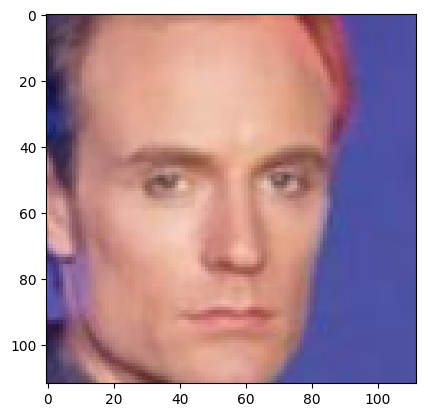

In [49]:
plt.imshow(celeba_dataset.alligned_images[np.random.randint(0, len(celeba_dataset.alligned_images))])

In [4]:
celeba_dataset = ProcessedDataset(DATA_DIR / "celeba_sample_embeddings")
# easy_geneset = ProcessedDataset(DATA_DIR / "easy_geneset_embeddings")
# medium_geneset = ProcessedDataset(DATA_DIR / "medium_geneset_embeddings")
# test_geneset = ProcessedDataset(DATA_DIR / "test_geneset_embeddings")
# lfw_dataset = ProcessedDataset(Path("/Users/czyjtu/dev/MP2023/data/lfw_dataset_embeddings"))

100%|██████████| 7/7 [00:00<00:00, 58.30it/s]


In [113]:
for name, emb in easy_geneset.model2embeddings.items():
    print(name, emb.shape)

layer3-29-bn3 (30332, 256)
arcface-r100 (30332, 512)
layer1-2-bn3 (30332, 64)
layer2-12-bn3 (30332, 128)
landmarks (30332, 136)
layer4-2-bn3 (30332, 512)
pca-combined-v1 (30332, 180)


# MLP Model

In [7]:
import torch
from torch import nn
import pytorch_lightning as pl
from torch.nn import functional as F


class DNARegressor(nn.Module):
    def __init__(self, input_size, output_size, hidden_sizes: list[int]):
        super(DNARegressor, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_size, hidden_sizes[0]))
        for i in range(1, len(hidden_sizes)):
            self.layers.append(nn.Linear(hidden_sizes[i-1], hidden_sizes[i]))
        self.layers.append(nn.Linear(hidden_sizes[-1], output_size))
    
    def forward(self, x):
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        x = self.layers[-1](x)
        return x
    

class MLP(pl.LightningModule):
    def __init__(self, model: nn.Module):
        super(MLP, self).__init__()
        self.model = model 
        self.save_hyperparameters()

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.forward(x)
        loss = F.mse_loss(y_pred, y)
        self.log('train_loss', loss, on_epoch=True, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.forward(x)
        loss = F.mse_loss(y_pred, y)
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        x, y = batch
        y_pred = self.forward(x)
        loss = F.mse_loss(y_pred, y)
        self.log("test_loss", loss, on_epoch=True, prog_bar=True)
        return loss

In [5]:
model = load_insightface_model("../../thirdparty/recognition/weights/arcface_r100.pth")

In [6]:
m = dict(model.named_modules())

In [7]:
layers_to_hook = [list(k for k in m.keys() if f"layer{i}" in k)[-1] for i in range(1, 5)]
layers_to_hook 

['layer1.2.bn3', 'layer2.12.bn3', 'layer3.29.bn3', 'layer4.2.bn3']

In [153]:
class FeatureExtractor(torch.nn.Module):
    def __init__(self, model, layer_names):
        super(FeatureExtractor, self).__init__()
        self.model = model
        self.layer_names = layer_names
        self.outputs = []

        # Register hooks
        for layer_name in self.layer_names:
            layer = dict([*self.model.named_modules()])[layer_name]
            layer.register_forward_hook(self.hook_fn)

    def hook_fn(self, module, input, output):
        self.outputs.append(output)

    def forward(self, x):
        self.outputs = []  # Reset outputs before each forward pass
        o = self.model(x)
        return list(self.outputs) + [o]
    
    def batch_forward(self, x, batch_size):
        partials = batch_predict(self, x, batch_size=batch_size)
        n_outputs = len(self.layer_names)
        batches_per_layer = [list() for _ in range(n_outputs)]
        for batch_output in partials:
            for i in range(n_outputs):
                batches_per_layer[i].append(batch_output[i])
        return [torch.concatenate(l) for l in batches_per_layer]


def batch_predict(model, input, batch_size):
    partial_output = []
    total_batches = len(input) // batch_size
    for batch_start in tqdm(range(0, len(input), batch_size), total=total_batches):
        batch = input[batch_start: batch_start + batch_size]
        partial_output.append(model(batch))
    return partial_output
    
import torchvision.transforms as VT

def get_earlier_layers_features(model, layers_to_hook, X: np.ndarray) -> list[np.ndarray]:
    transform = VT.Compose([
        VT.ToTensor(),
        VT.Resize((112, 112)),
        VT.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    X_th = torch.stack([transform(img) for img in tqdm(X)])
    fe = FeatureExtractor(model, layers_to_hook)
    with torch.no_grad():
        features: list[torch.Tensor] = fe.batch_forward(X_th, 64)
    return [f.view(*f.size()[:2], -1).mean(-1).detach().cpu().numpy() for f in features]

def save_features_from_layers(model, layers_to_hook, X, output_dir: Path) -> None: 
    features = get_earlier_layers_features(model, layers_to_hook, X)
    output_dir.mkdir(parents=True, exist_ok=True)

    layer_names = ["embeddings_" + "_".join(l.split(".")) for l in layers_to_hook]
    for feat, fname in zip(features, layer_names):
        np.save(output_dir / fname, feat)
            

In [11]:
[ s.shape for s in get_earlier_layers_features(model, layers_to_hook, np.moveaxis(celeba_dataset.alligned_images[:100],-1, 1))]

2it [00:08,  4.38s/it]                       


[(100, 64), (100, 128), (100, 256), (100, 512)]

: 

# test whether embeddings correlate with skin color

In [10]:
import matplotlib.pyplot as plt 

In [11]:

X_train_sc, X_val_sc, X_test_sc, Y_train, Y_val, Y_test, train_images, val_images, test_images, scaler_x = load_geneset_dataset(GENESET)

100%|██████████| 1/1 [00:00<00:00, 79.32it/s]


In [12]:
skin_color = X_train_sc[:, 2]

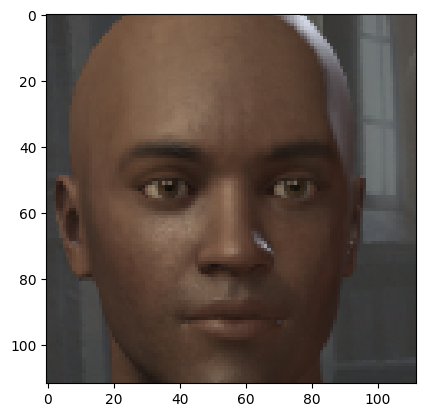

0.849673202614379


In [17]:
def plot(i):
    plt.imshow(train_images[i])
    plt.show()
    print(skin_color[i])

plot(np.random.randint(0, skin_color.shape[0]))

### test correlation

In [141]:
def corr(a: np.ndarray, b: np.ndarray):
    a_centered = a - a.mean()
    b_centered = b - b.mean()
    return np.sum(a_centered * b_centered) / \
        np.sqrt((a_centered ** 2).sum() * (b_centered ** 2).sum())

In [19]:
pearsonr = np.array([corr(skin_color, Y_train[:, i]) for i in range(Y_train.shape[1])])

<BarContainer object of 512 artists>

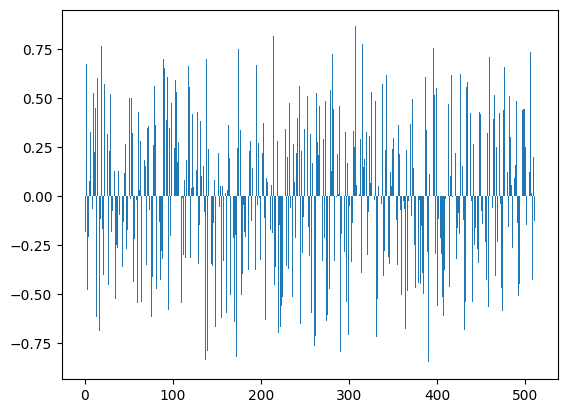

In [20]:
plt.bar(range(512), pearsonr)

## Visualize data

In [17]:
# get first two components of PCA
pca = PCA(n_components=10)
pca.fit(Y_train)
Y_train_pca = pca.transform(Y_train)
# print % of variance explained
pca.explained_variance_ratio_

array([0.20867021, 0.15101111, 0.08574304, 0.07283967, 0.06265148,
       0.05136691, 0.04289678, 0.03753795, 0.02902666, 0.02475439],
      dtype=float32)

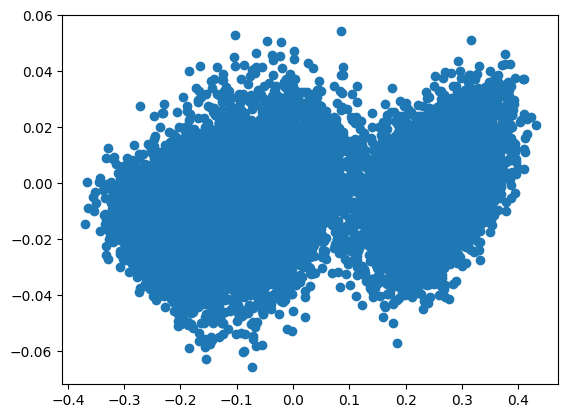

In [16]:
plt.scatter(Y_train_pca[:, 0], Y_train[:, 1])

# features from earlier leayers 

In [15]:
embeddings_to_test = sorted(list(medium_geneset.model2normalized_embeddings.keys()))
embeddings_to_test

['arcface-r100',
 'clip',
 'landmarks',
 'layer1-2-bn3',
 'layer2-12-bn3',
 'layer3-29-bn3',
 'layer4-2-bn3',
 'pca-combined-v1']

In [17]:
def analyze(ck_dataset, real_dataset, ck_name, real_name, embeddings_to_test):
    for emb in embeddings_to_test:
        if "pca" in emb: continue 
        print(emb)
        # do PCA for easy geneset and celeba_dataset 
        pca_easy = PCA(n_components=10)
        pca_easy.fit(ck_dataset.model2normalized_embeddings[emb])
        ck_dataset_pca = pca_easy.transform(ck_dataset.model2normalized_embeddings[emb])
        pca_lfw = PCA(n_components=10)
        pca_lfw.fit(real_dataset.model2normalized_embeddings[emb])
        lfw_dataset_pca = pca_lfw.transform(real_dataset.model2normalized_embeddings[emb])
        # plot PCA side by side 
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].scatter(ck_dataset_pca[:, 0], ck_dataset_pca[:, 1])
        ax[0].set_title(ck_name)
        ax[1].scatter(lfw_dataset_pca[:, 0], lfw_dataset_pca[:, 1])
        ax[1].set_title(real_name)
        plt.show()
        # display bar plot with explained variances by components side by side 
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].bar(range(10), pca_easy.explained_variance_ratio_)
        ax[0].set_title(ck_name)
        ax[1].bar(range(10), pca_lfw.explained_variance_ratio_)
        ax[1].set_title(real_name)
        plt.show()
        # do umap for easy geneset and real_dataset combined
        from umap import UMAP
        umap = UMAP(n_components=2)
        umap.fit(np.concatenate([ck_dataset.model2normalized_embeddings[emb], real_dataset.model2normalized_embeddings[emb]]))
        ck_dataset_umap = umap.transform(ck_dataset.model2normalized_embeddings[emb])
        lfw_dataset_umap = umap.transform(real_dataset.model2normalized_embeddings[emb])
        # plot both umaps on the same plot
        plt.scatter(ck_dataset_umap[:, 0], ck_dataset_umap[:, 1], label=ck_name, s=0.1, alpha=0.1)
        plt.scatter(lfw_dataset_umap[:, 0], lfw_dataset_umap[:, 1], label=real_name, s=1, alpha=0.5)
        plt.legend()
        plt.show()
    

## Easy vs celeba

arcface-r100


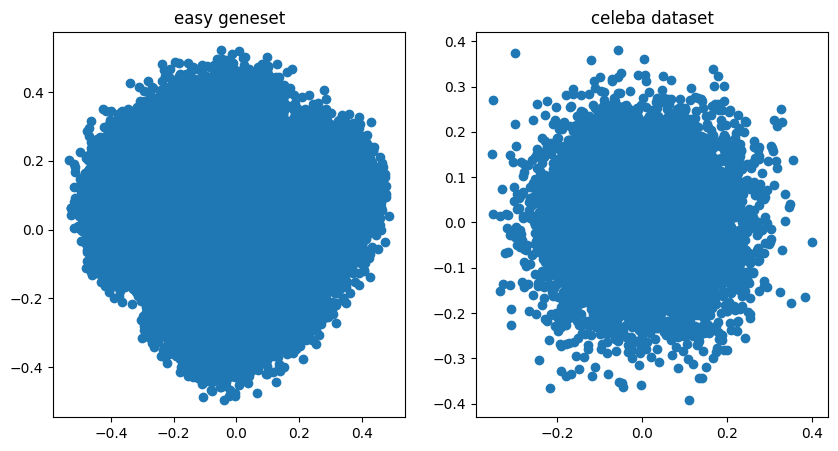

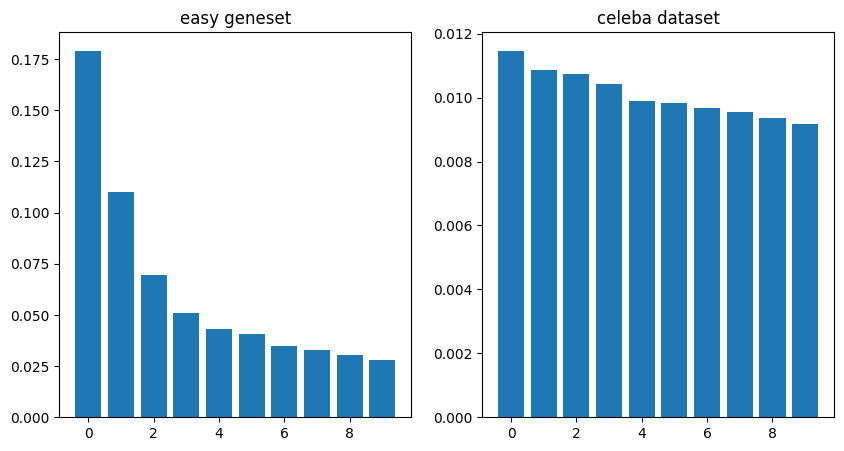

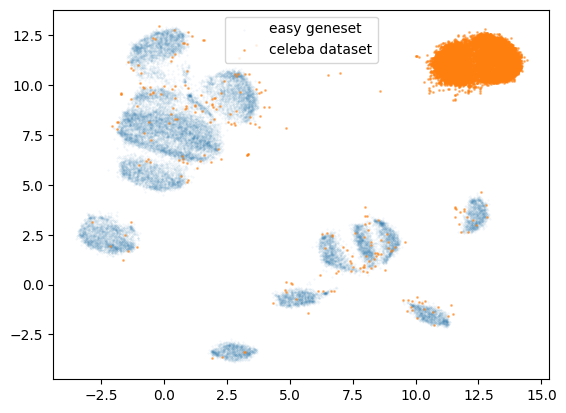

clip


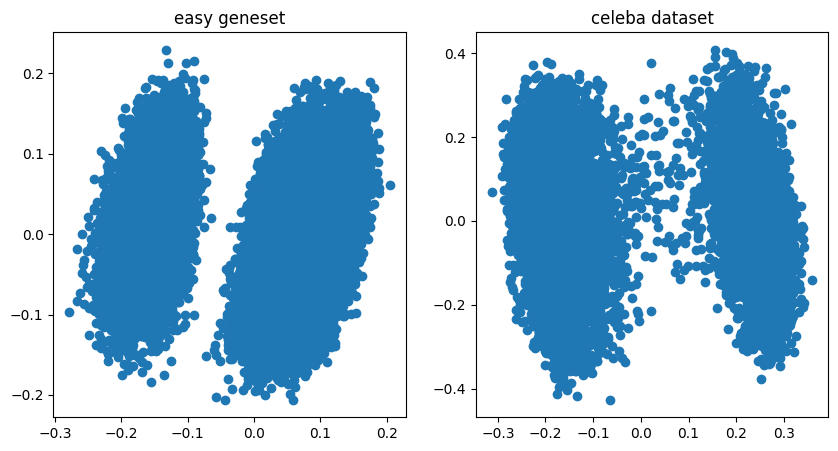

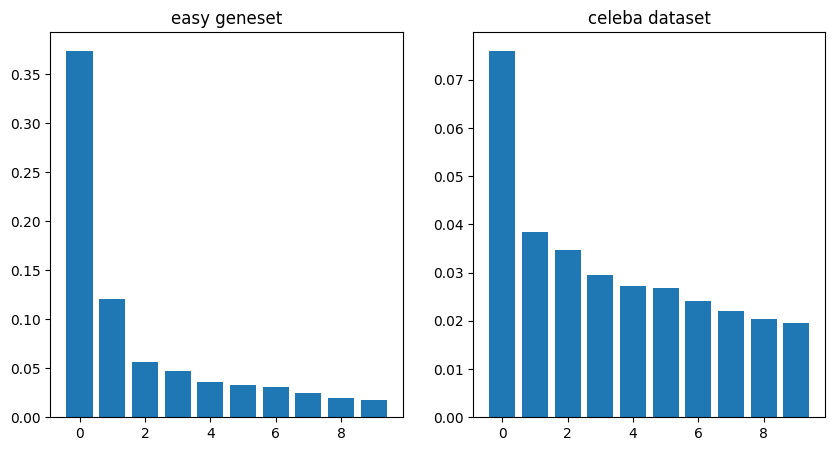

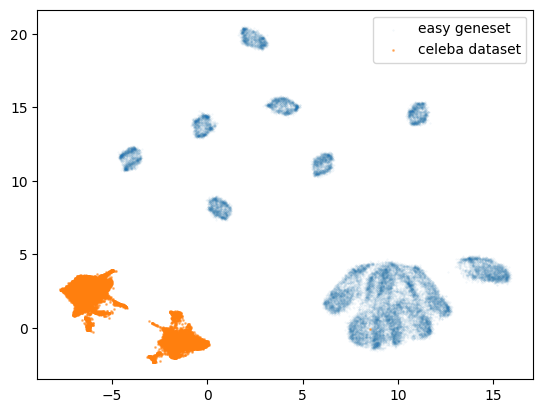

landmarks


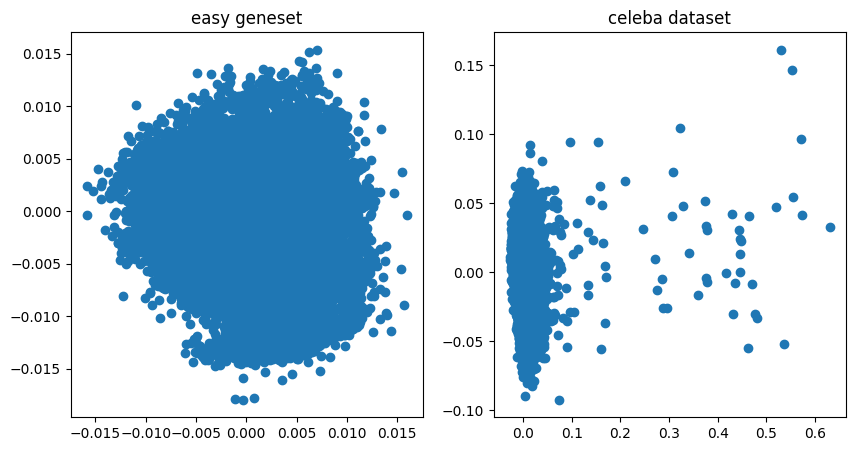

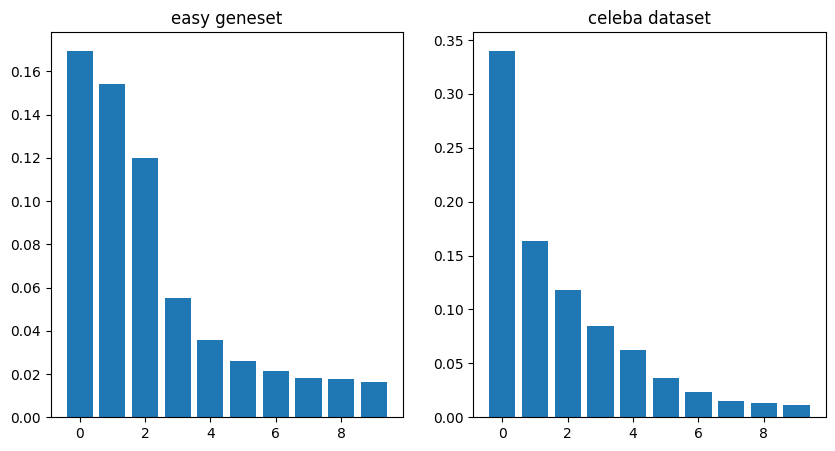

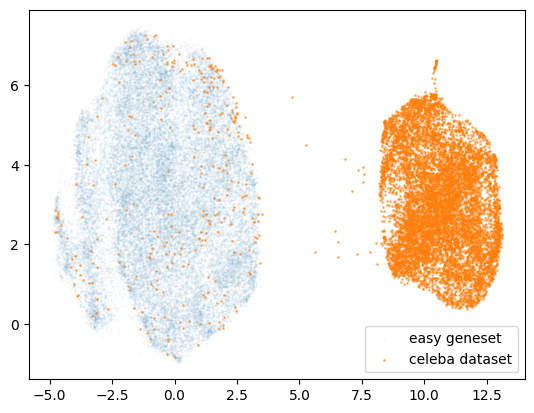

layer1-2-bn3


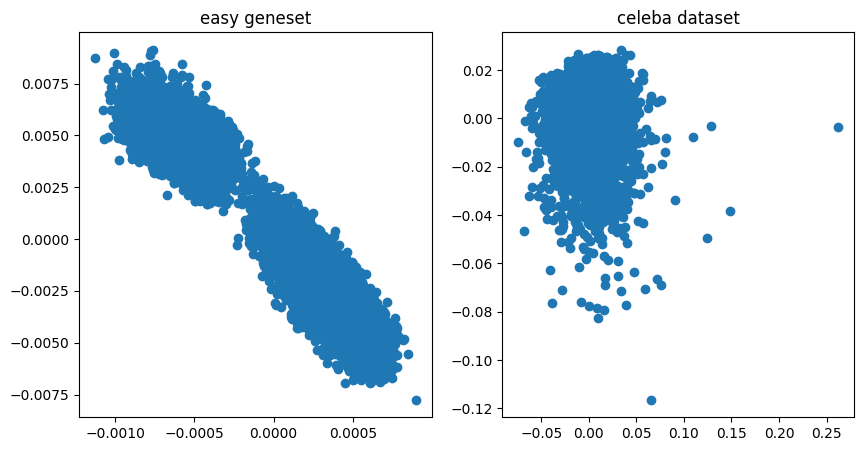

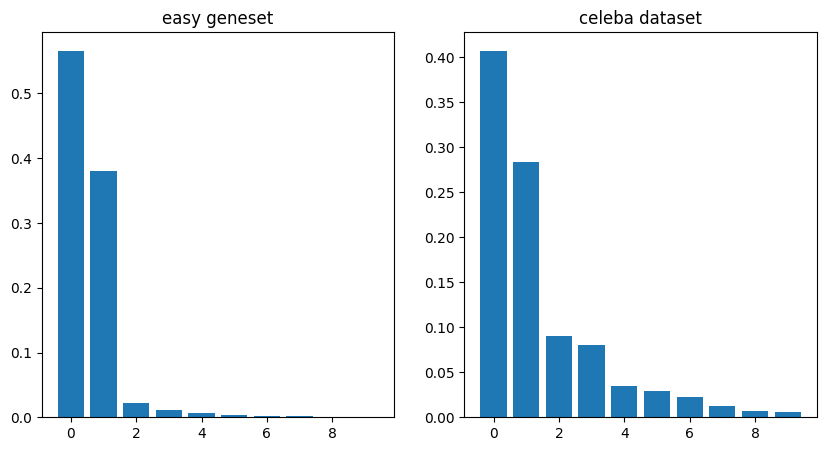

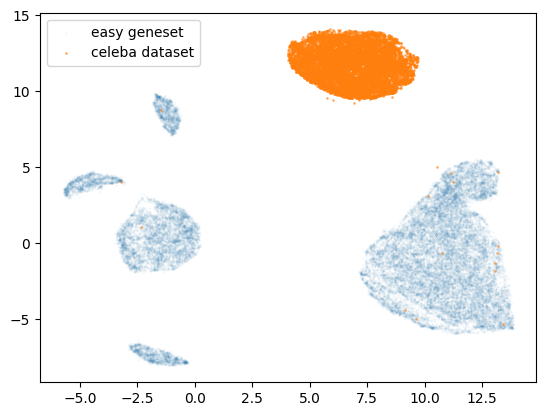

layer2-12-bn3


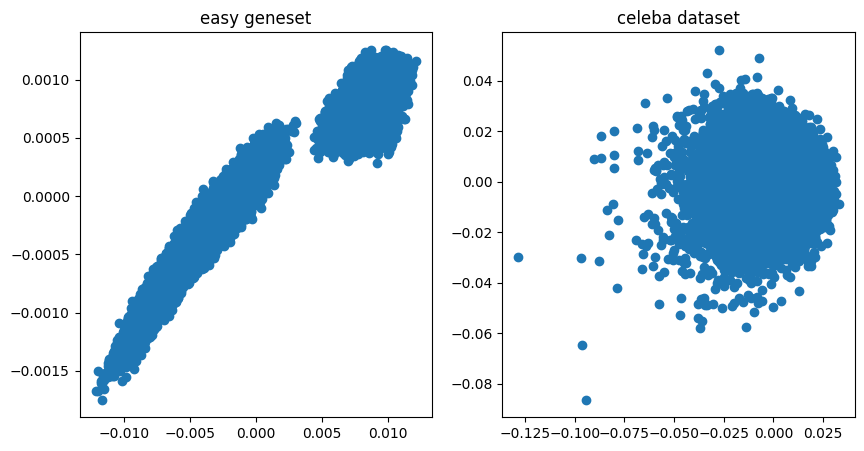

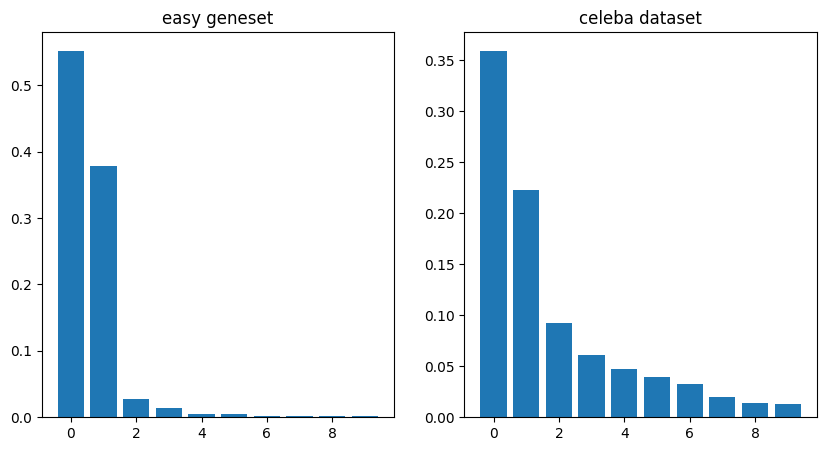

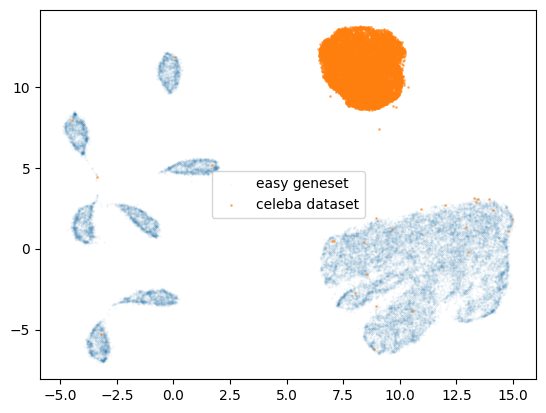

layer3-29-bn3


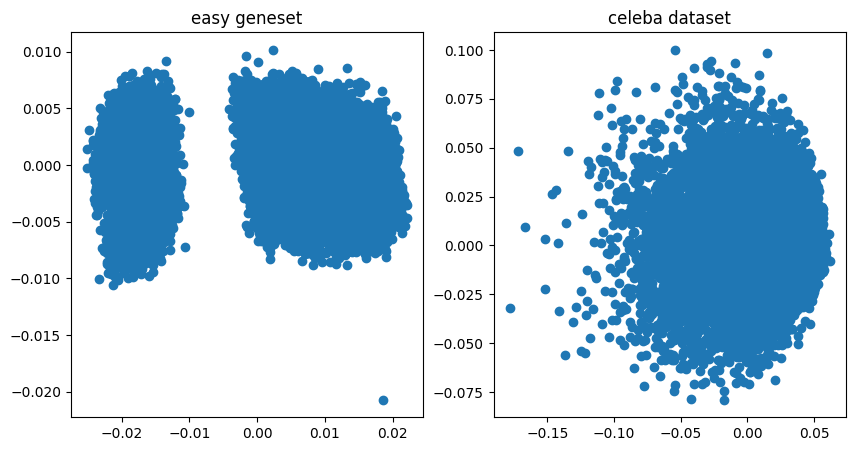

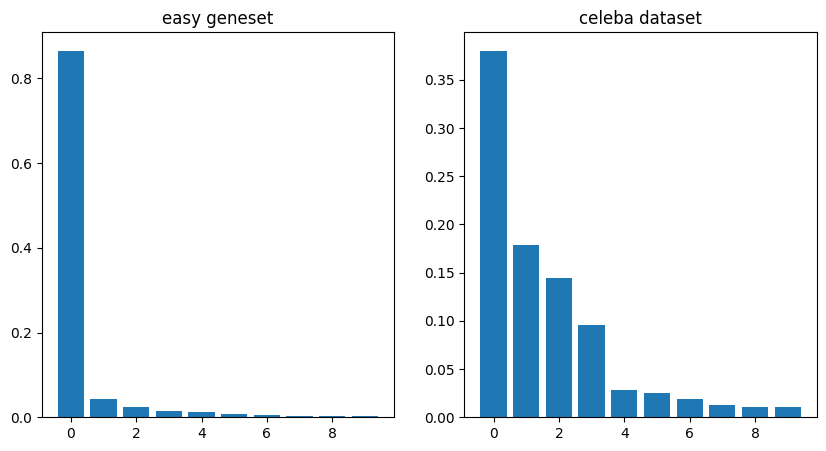

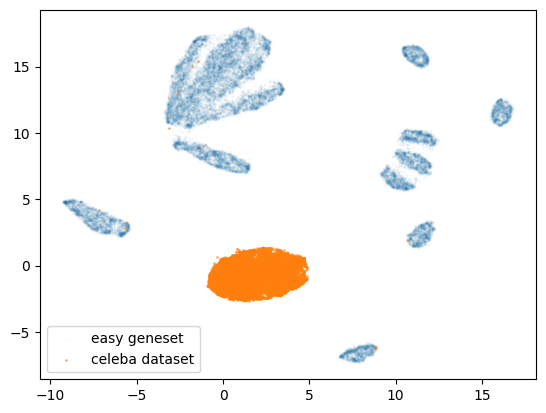

layer4-2-bn3


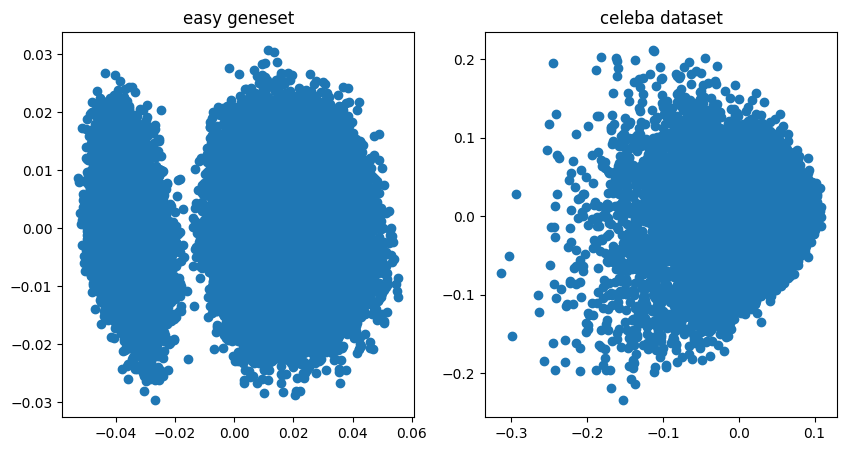

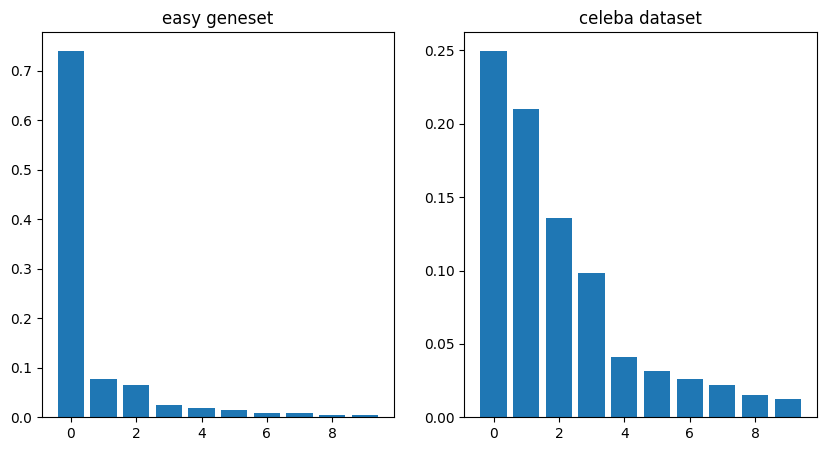

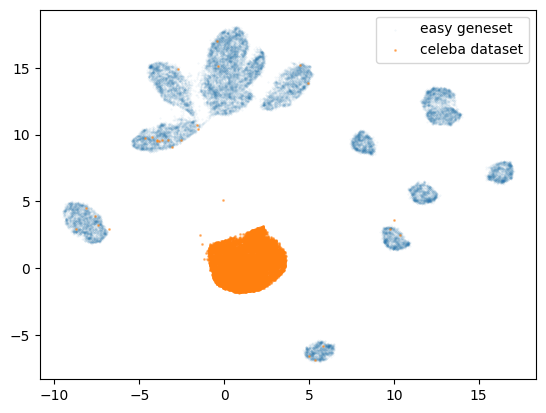

In [18]:
analyze(easy_geneset, celeba_dataset, "easy geneset", "celeba dataset", embeddings_to_test)

## medium vs celeba

arcface-r100


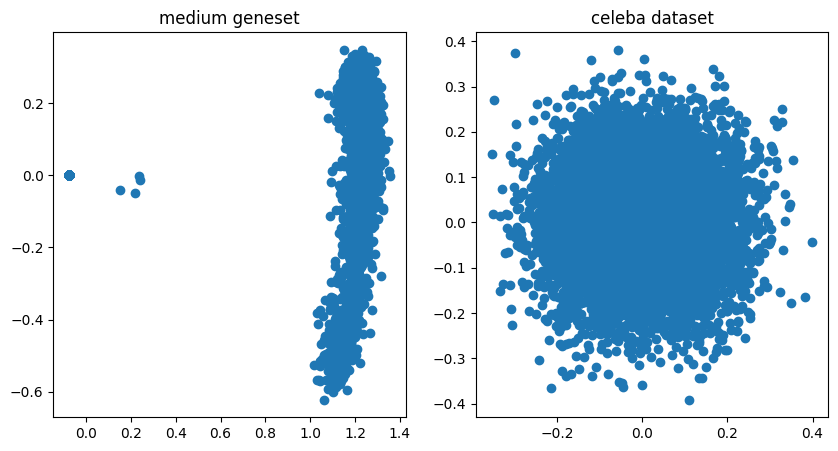

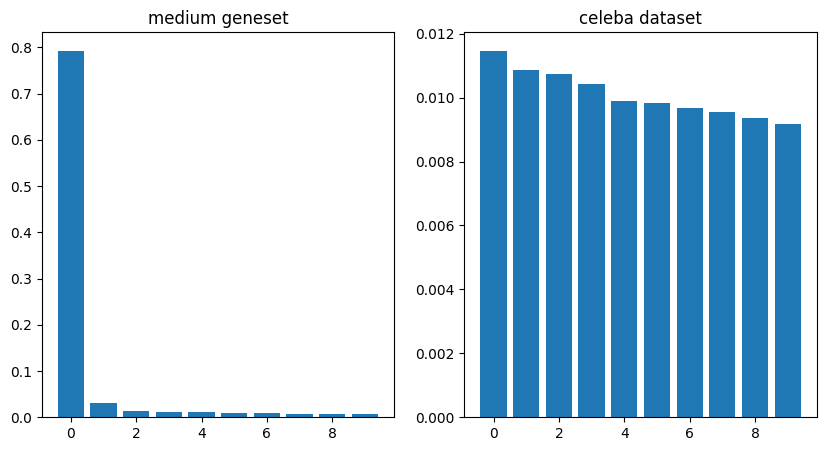

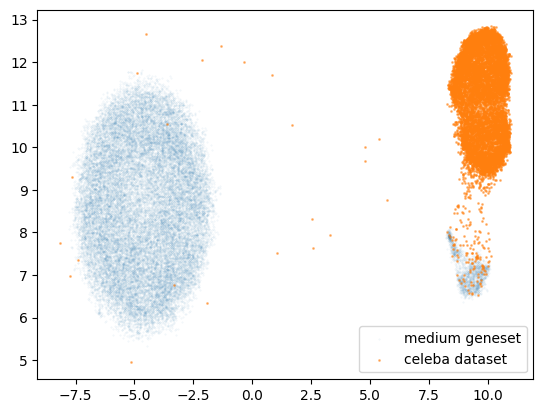

clip


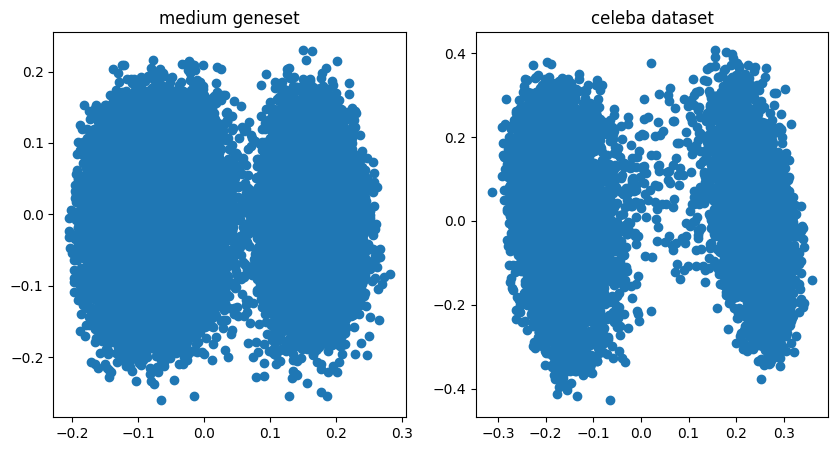

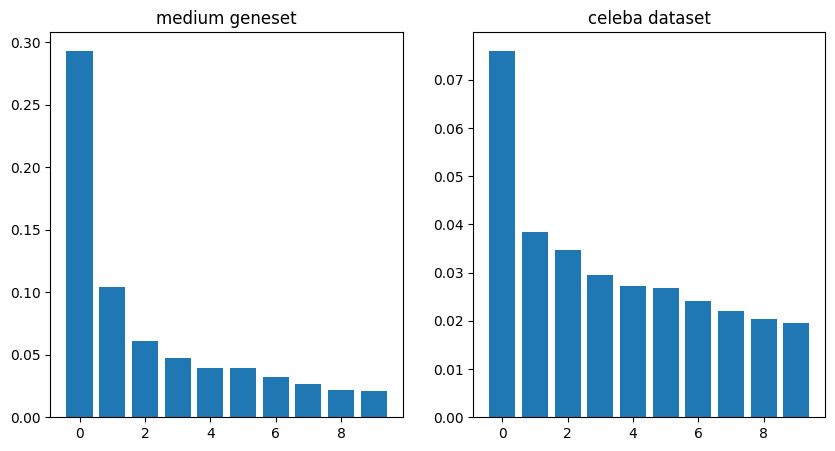

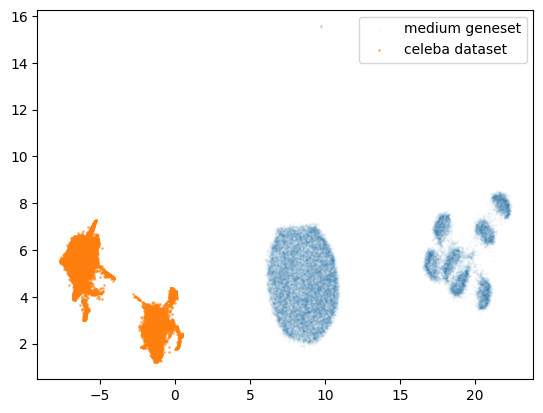

landmarks


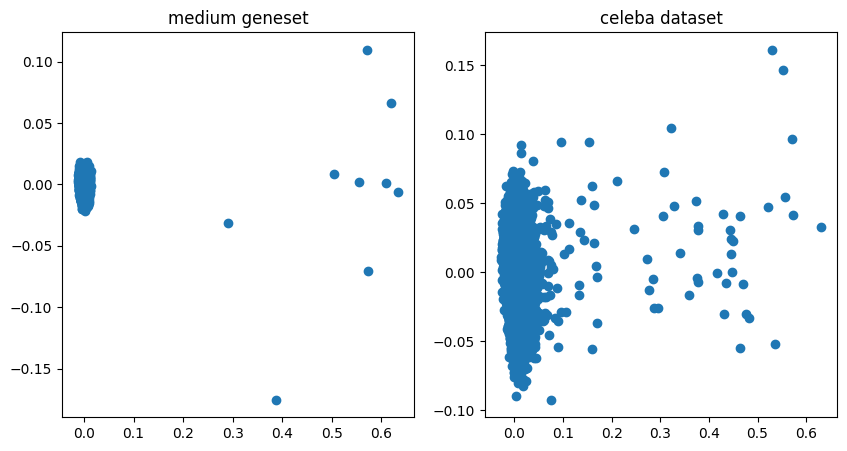

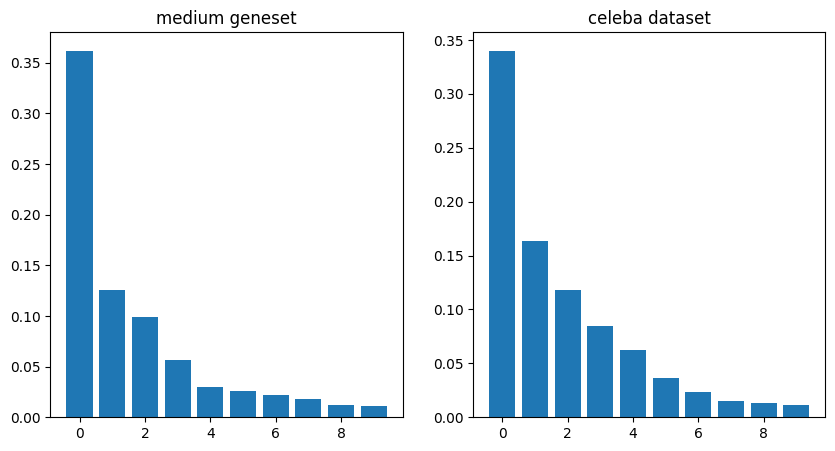

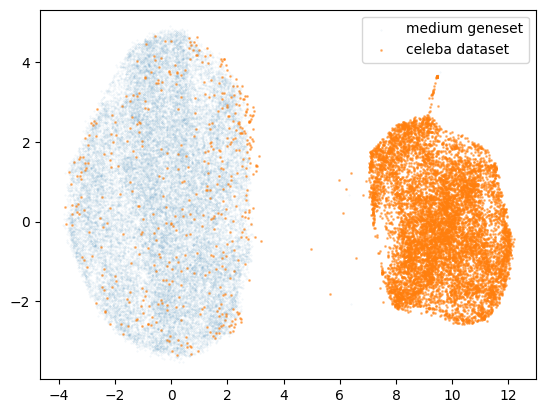

layer1-2-bn3


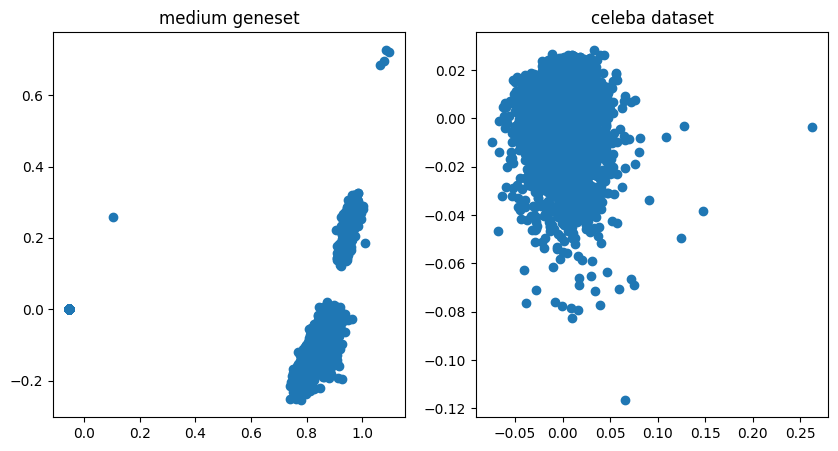

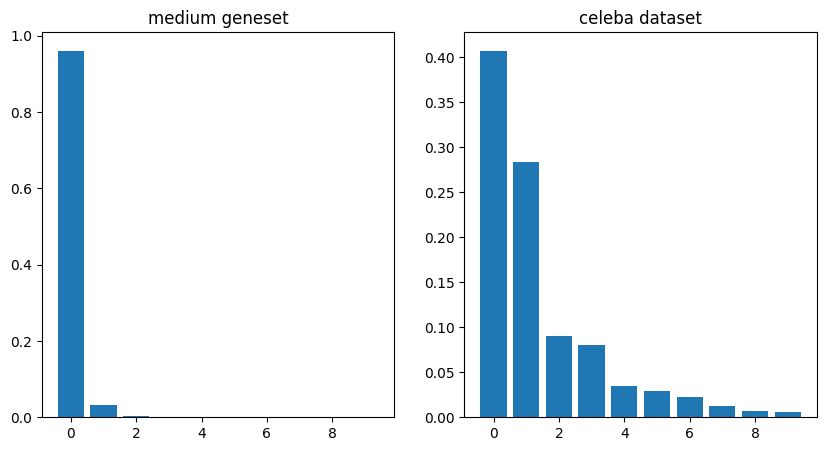

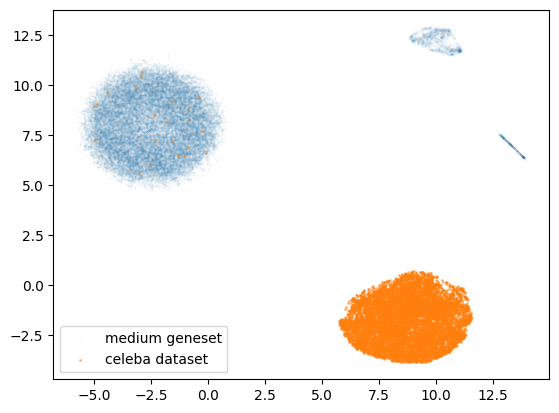

layer2-12-bn3


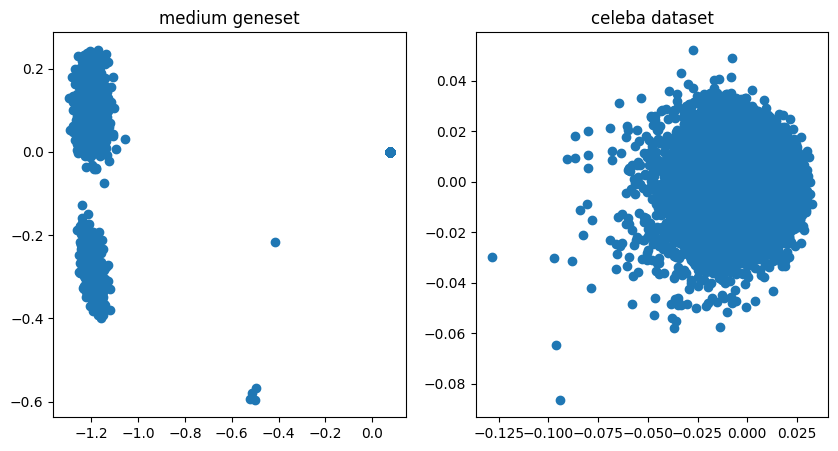

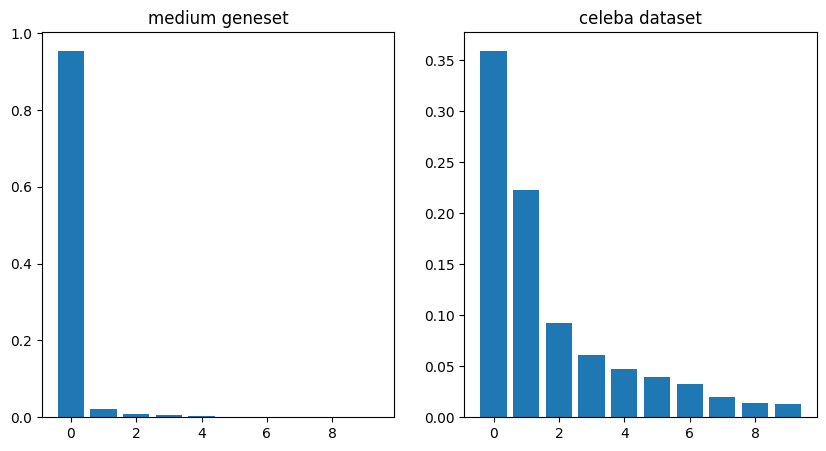

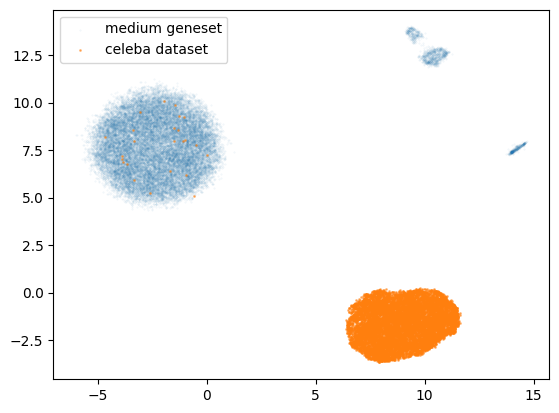

layer3-29-bn3


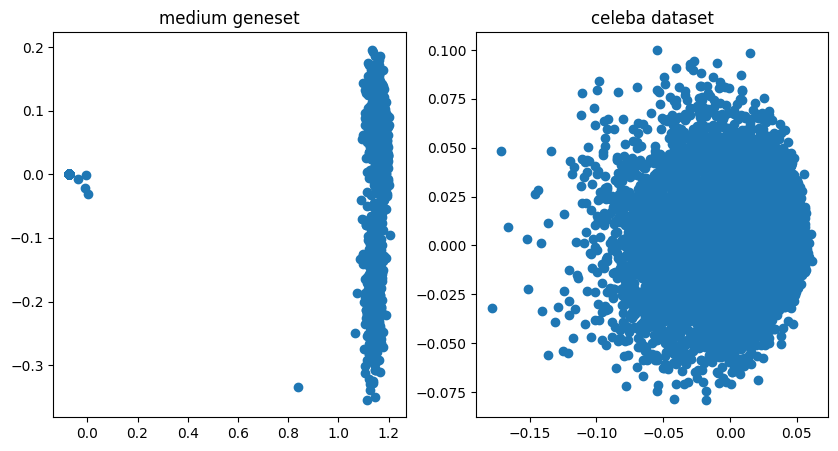

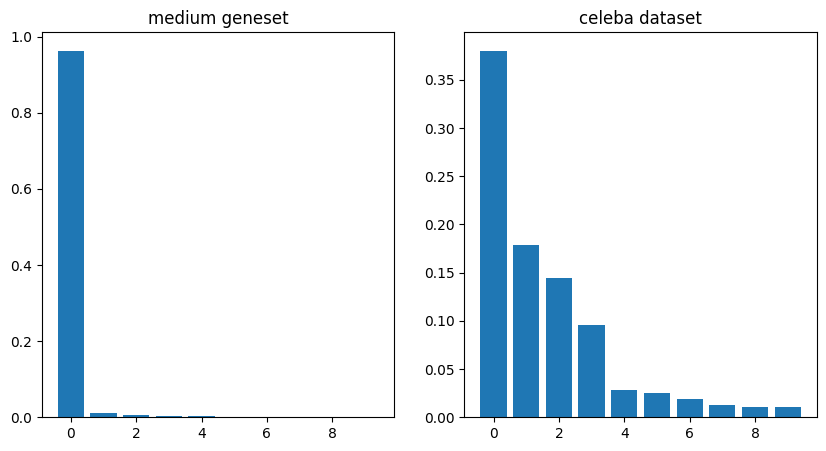

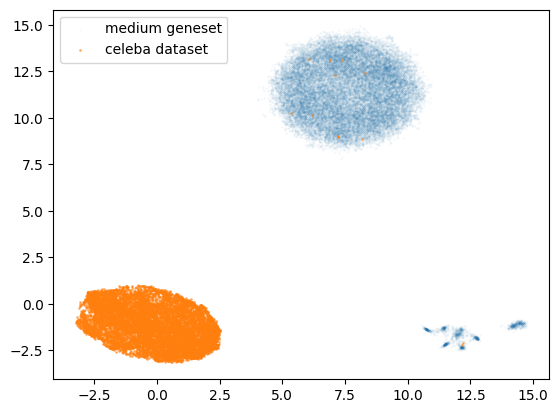

layer4-2-bn3


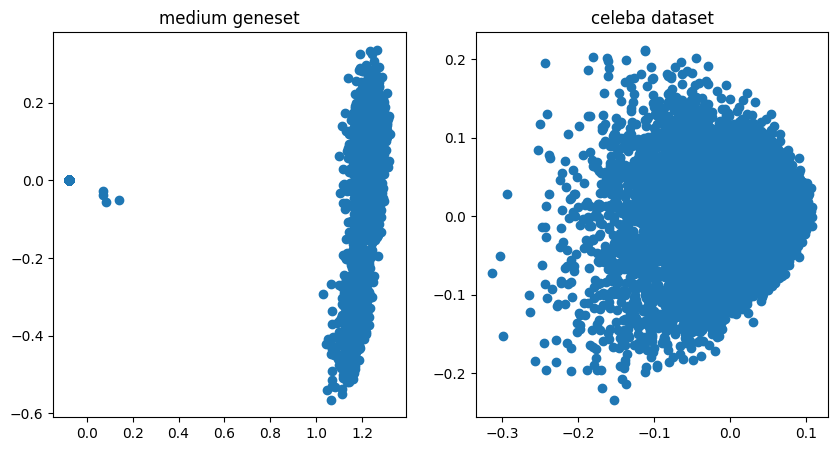

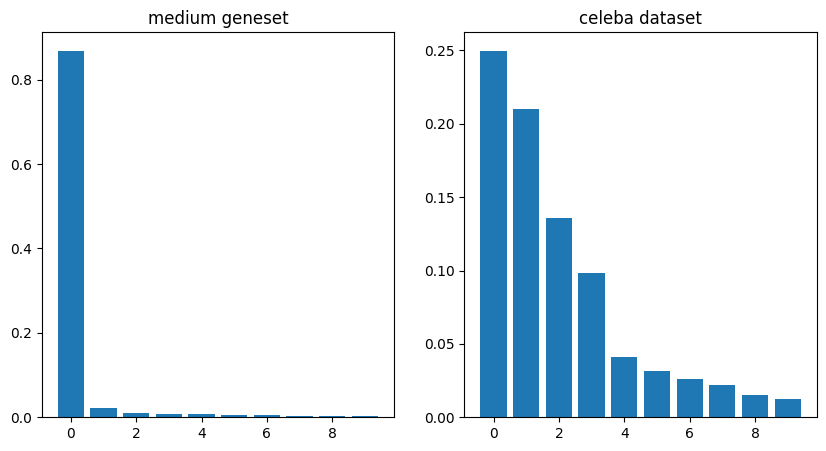

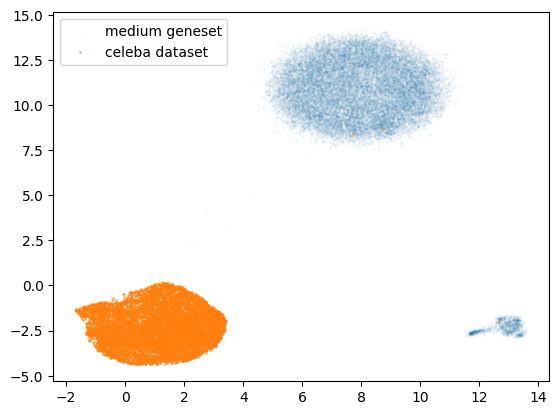

In [19]:
analyze(medium_geneset, celeba_dataset, "medium geneset", "celeba dataset", embeddings_to_test)

## Test vs celeba

arcface-r100


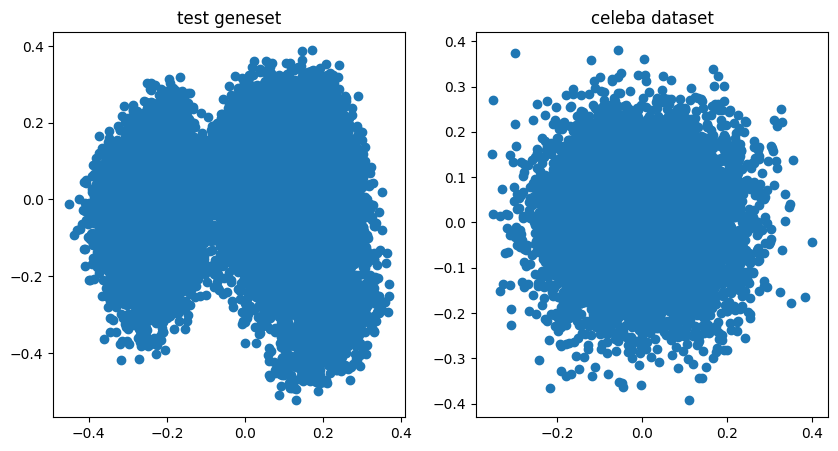

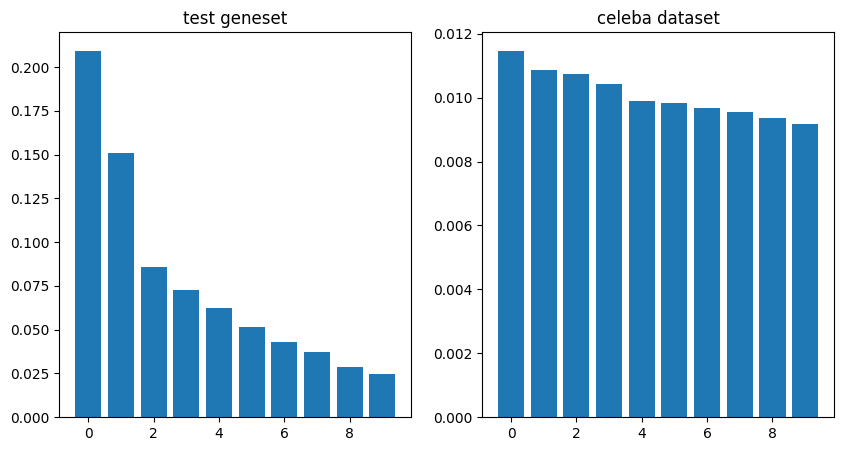

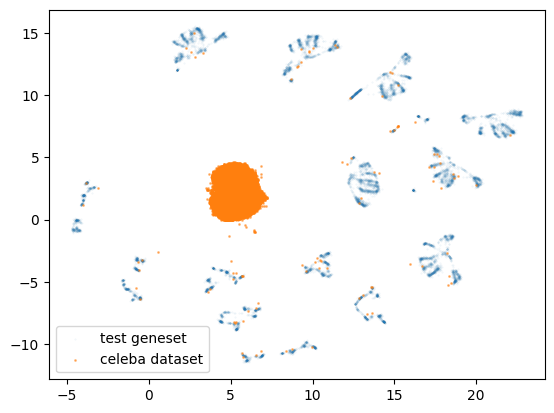

clip


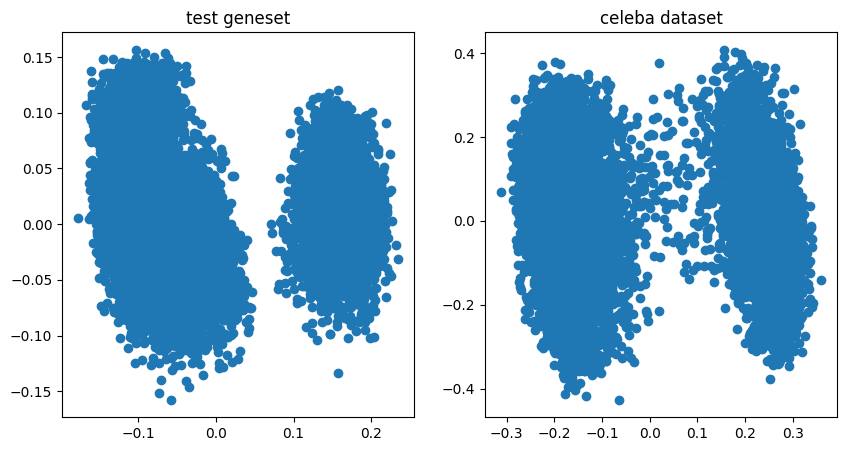

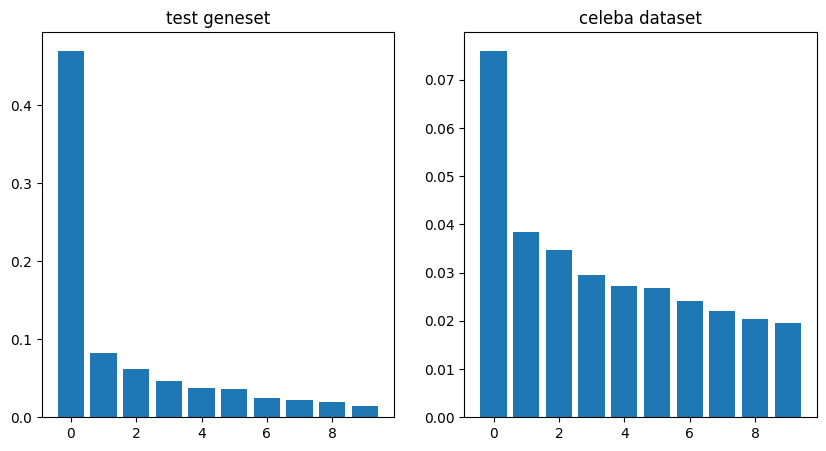

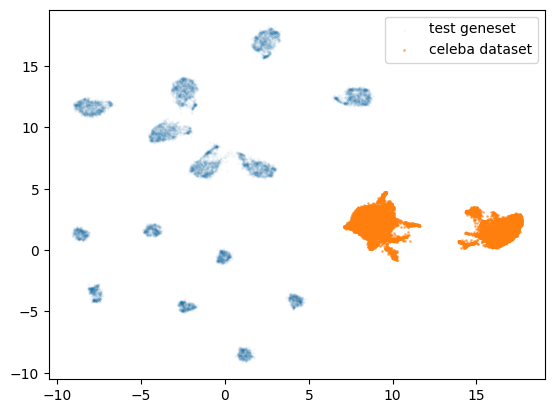

In [21]:
analyze(test_geneset, celeba_dataset, "test geneset", "celeba dataset", test_geneset.model2normalized_embeddings.keys())


## Medium vs test

arcface-r100


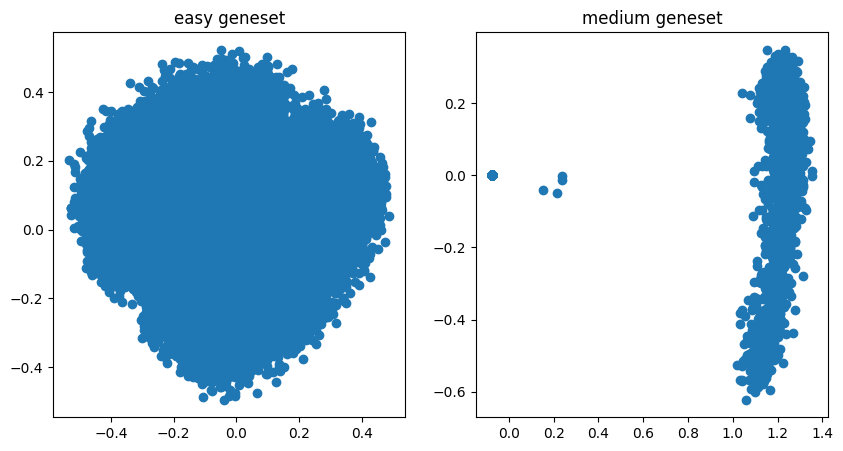

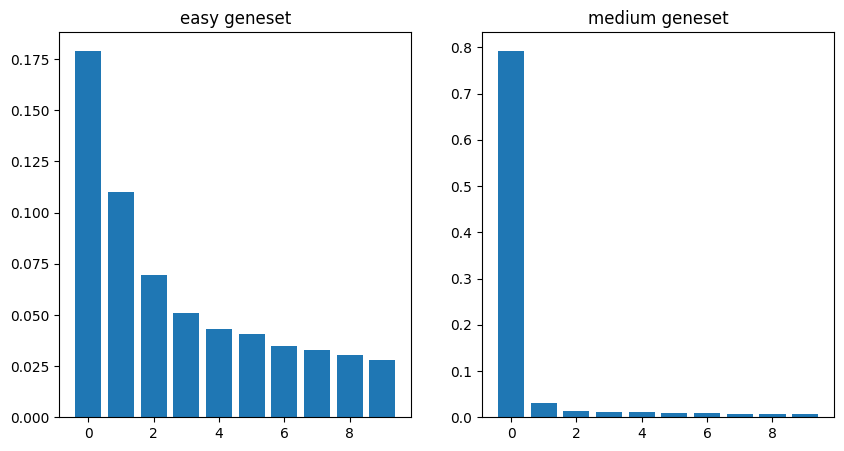

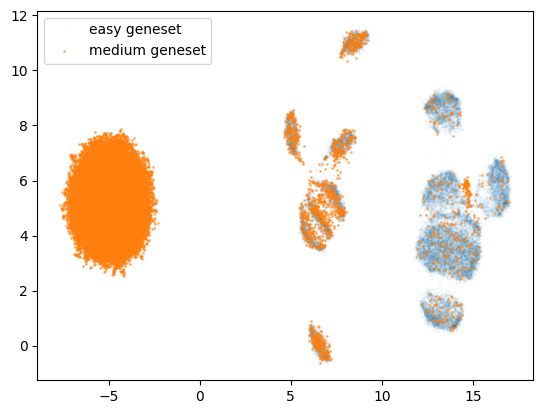

clip


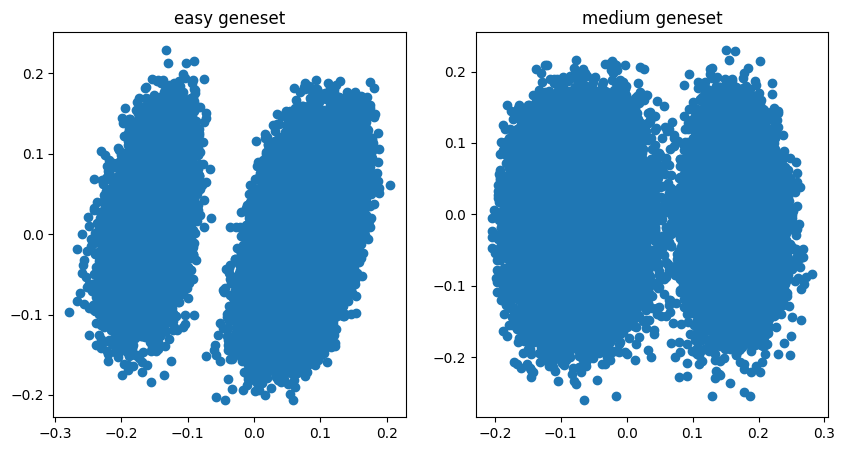

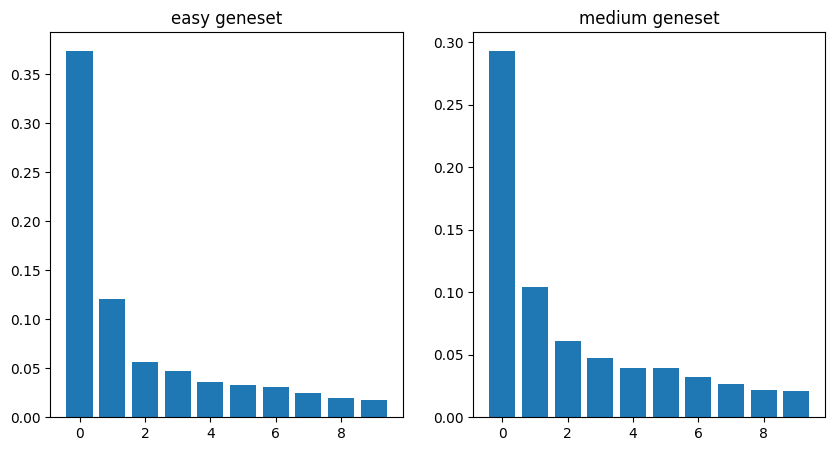

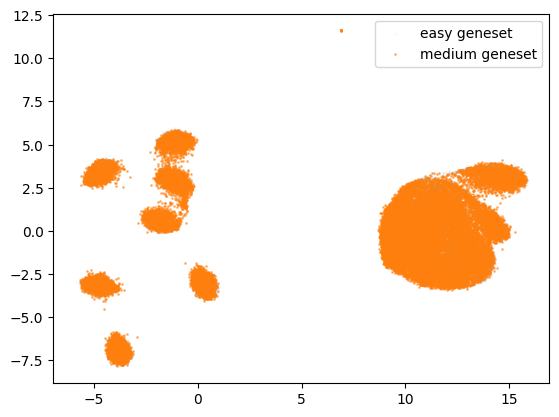

landmarks


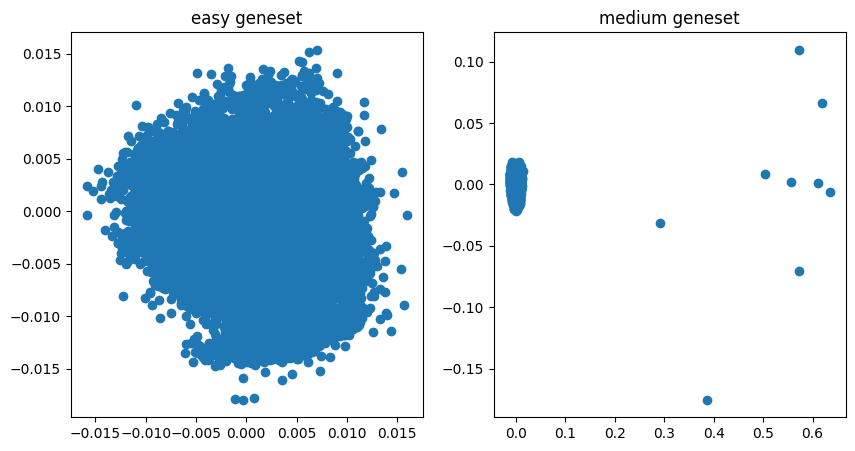

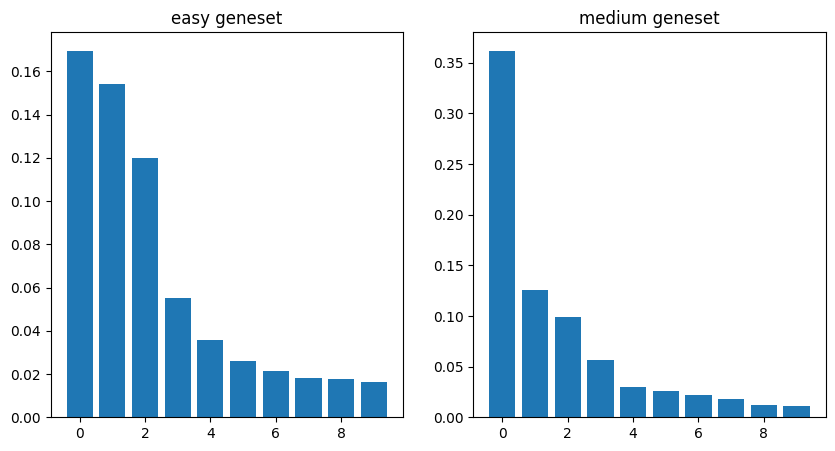

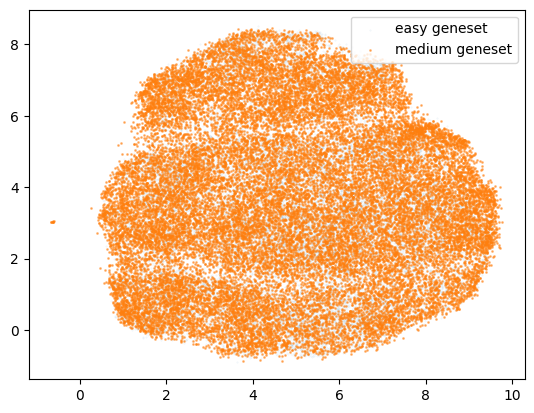

layer1-2-bn3


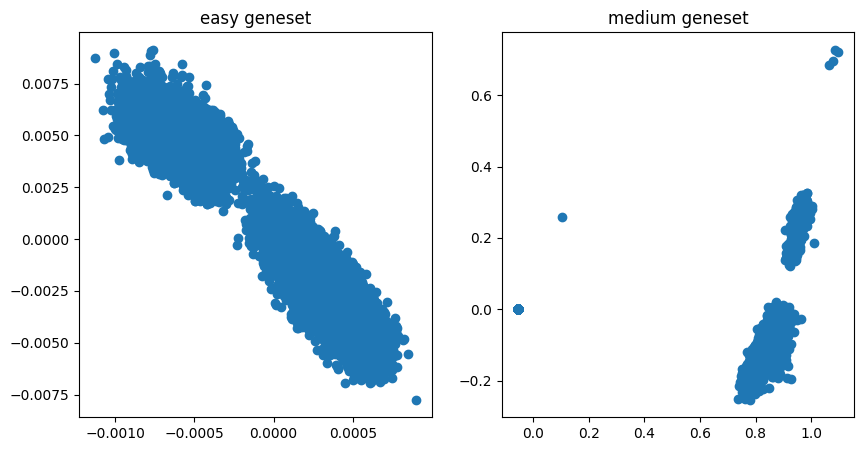

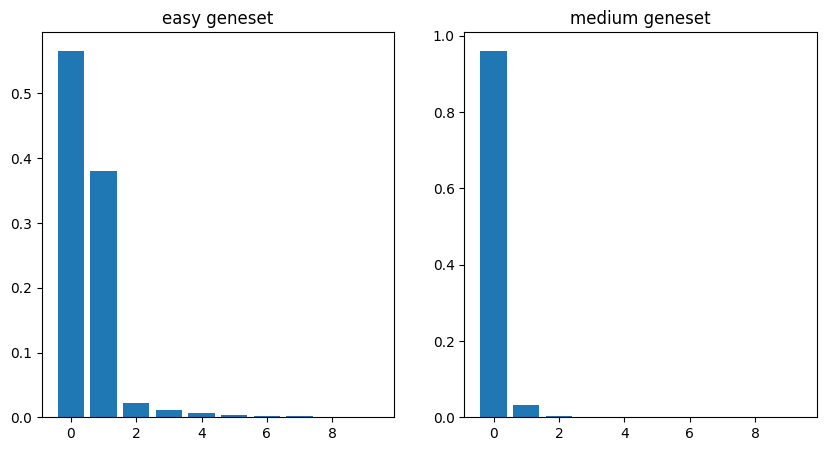

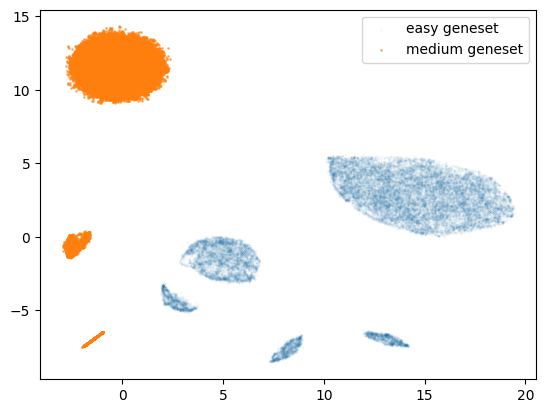

layer2-12-bn3


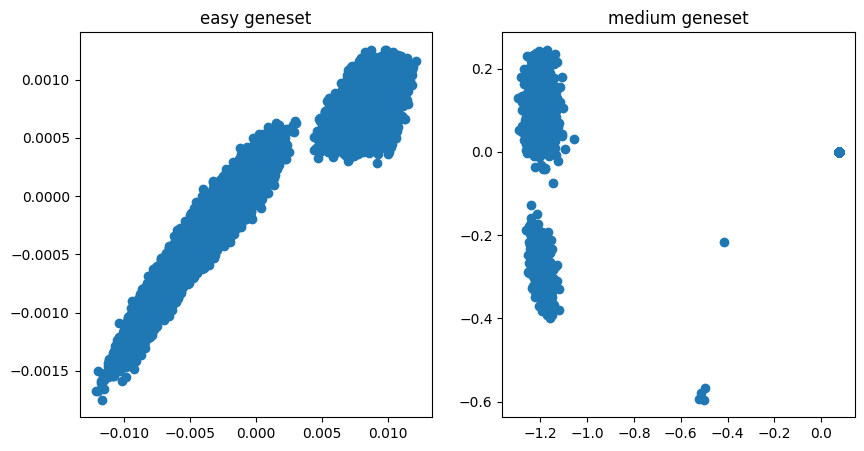

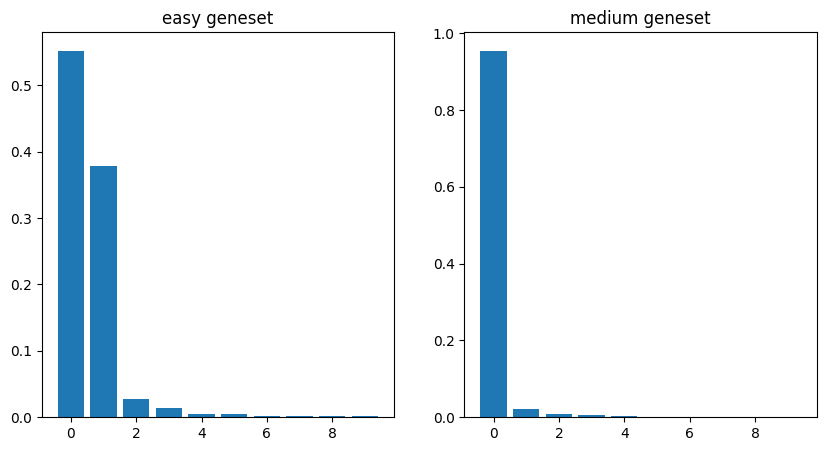

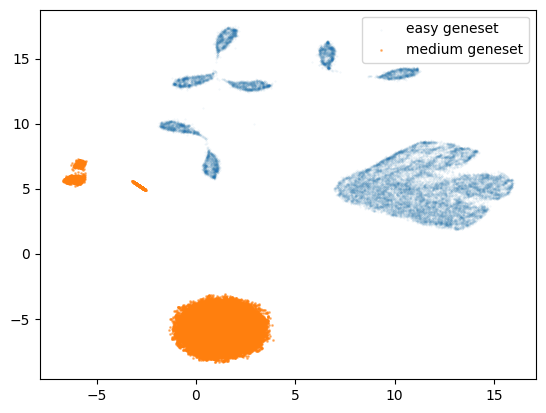

layer3-29-bn3


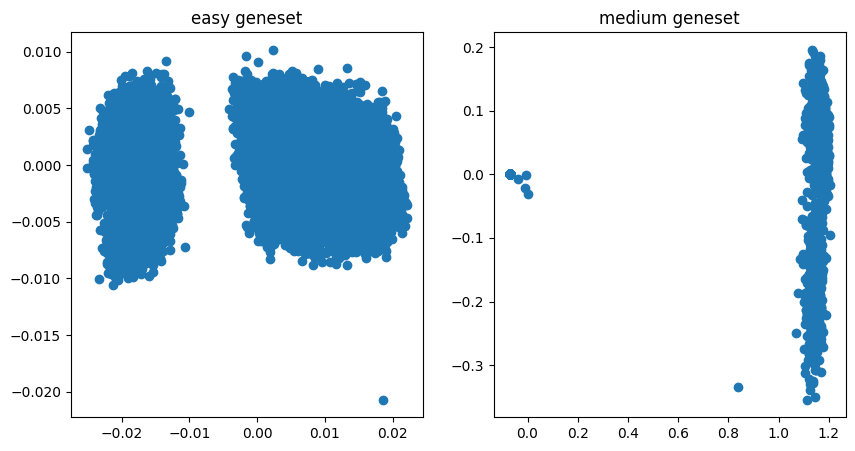

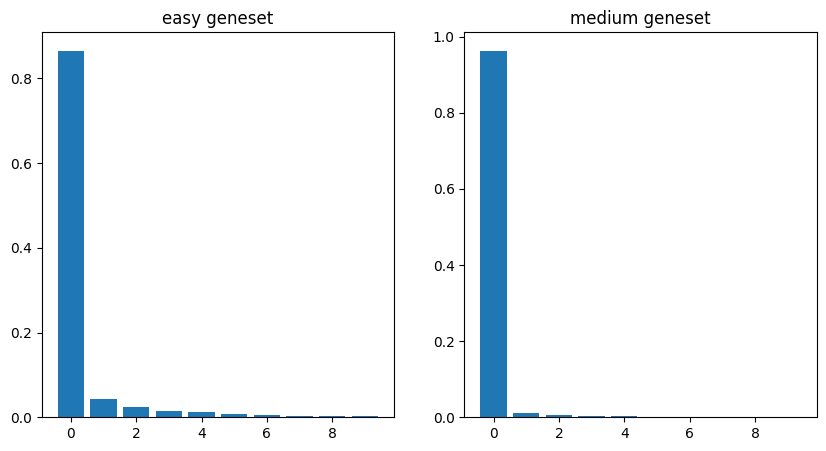

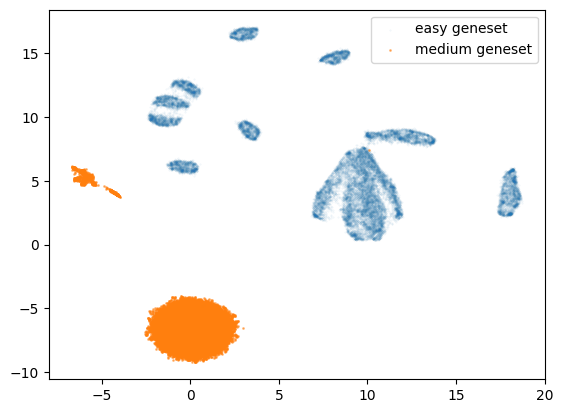

layer4-2-bn3


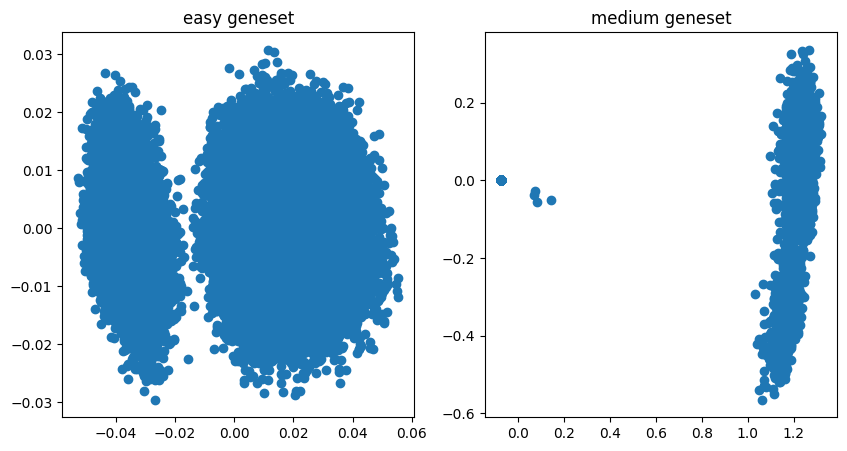

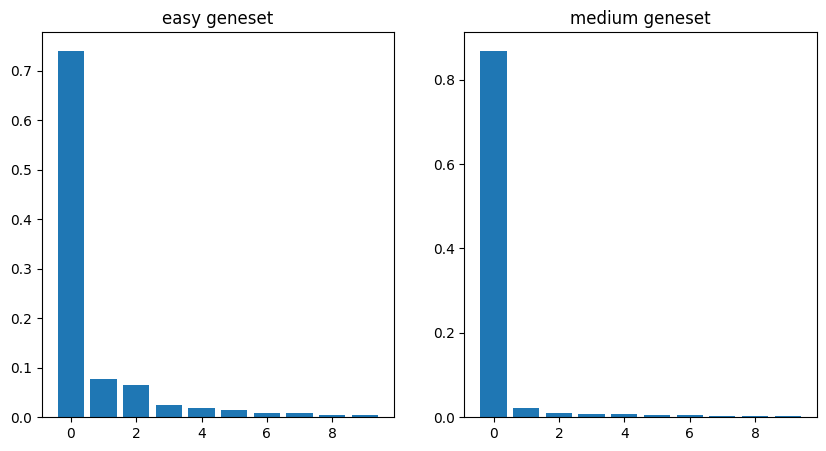

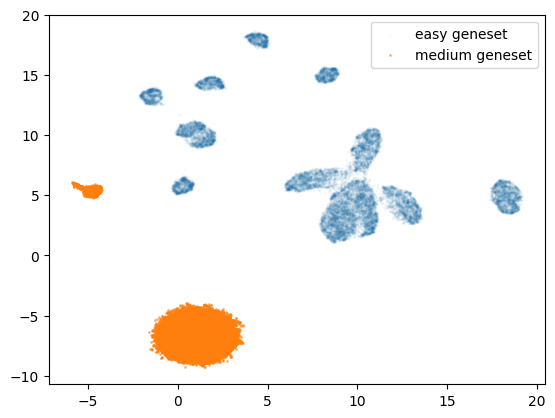

In [24]:
analyze(easy_geneset, medium_geneset, "easy geneset", "medium geneset", embeddings_to_test)

# train model on new features

In [9]:
# for each embeddings, do PCA to retrieve 90% of variability of each embeddings
# for each embeddings, do UMAP to visualize embeddings in 2D

def reduce_dimensionality(embeddings: np.ndarray):
    pca = PCA(n_components=0.95)
    pca.fit(embeddings)
    pca_embeddings = pca.transform(embeddings)
    return pca_embeddings, pca 

reduced_features = {}
pcas = {}
for name, emb in easy_geneset.model2normalized_embeddings.items():
    reduced_features[name], pcas[name] = reduce_dimensionality(emb)
    print(f"{name}: {reduced_features[name].shape}")



layer3-29-bn3: (14990, 2)
arcface-r100: (30332, 73)
layer1-2-bn3: (14990, 3)
layer2-12-bn3: (14990, 2)
landmarks: (30332, 89)
layer4-2-bn3: (14990, 5)


# CelebA skin color estimation

In [1]:
def rgb2gray(rgb):
    r, g, b = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]
    gray = 0.2989 * r + 0.5870 * g + 0.1140 * b
    return gray

def estimate_skin_darkness(image):
    roi = image[65:75, 72:82, :]
    return 1 - rgb2gray(roi).mean() / 255

im = celeba_dataset.alligned_images[np.random.randint(0, len(celeba_dataset.alligned_images))]
roi = im[65:75, 72:82, :]
print(rgb2gray(roi).mean() / 255)
plt.imshow(im)
plt.show()
plt.imshow(roi)
plt.show()
plt.imshow(rgb2gray(roi), cmap='gray')

NameError: name 'celeba_dataset' is not defined

## skin color estimations vs game gene

In [225]:
from utils.dataset import MEDIUIM_GENESET_GENES

def test_skin_color_correlation(model, geneset, skin_color_idx, geneset_dataset, embeddings, real_dataset):
    X, Y = get_raw_dataset(geneset, embeddings)
    ck_skin_color = X[:, skin_color_idx]
    ck_color_estimates = np.array([estimate_skin_darkness(im) for im in geneset_dataset.alligned_images])
    ck_mlp_color_estimates = torch.concatenate(batch_predict(model, torch.tensor(geneset_dataset.model2normalized_embeddings[embeddings]), 64))[:, skin_color_idx].detach().numpy()
    print(f"(CK) skin color feature vs skin color proxy: corr = {corr(ck_skin_color, ck_color_estimates)}")
    print(f"(CK) skin color proxy vs skin color prediction: corr = {corr(ck_color_estimates, ck_mlp_color_estimates)}")

    celeba_skin_color = np.array([estimate_skin_darkness(im) for im in real_dataset.alligned_images])
    mlp_celeba_skin_color = torch.concatenate(batch_predict(model, torch.tensor(real_dataset.model2normalized_embeddings[embeddings]), 64))[:, skin_color_idx].detach().numpy()
    print(f"(real) skin color proxy vs skin color prediction: corr = {corr(celeba_skin_color, mlp_celeba_skin_color)}")


model_paths = {
    ("test", "arcface-r100"): "../../experiments/test_geneset_embeddings/mlp_model.ckpt",
    ("easy", "pca-combined-v1"): "../../experiments/easy_geneset/pca_combined_v1/mlp_model.ckpt",
    ("medium", "arcface-r100"): "../../experiments/medium_geeset/arcface_r100/mlp_model.ckpt",
    ("medium", "pca-combined-v1"): "../../experiments/medium_geeset/pca-combined-v1/mlp_model.ckpt"
}


### test geneset

In [161]:
model = MLP.load_from_checkpoint(model_paths[("test", "arcface-r100")]).to("cpu")
test_skin_color_correlation(model, "test", -1, test_geneset, "arcface-r100", celeba_dataset)

/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
100%|██████████| 1/1 [00:00<00:00, 164.31it/s]
235it [00:00, 7530.86it/s]             


(CK) skin color feature vs skin color proxy: corr = 0.977061596675807
(CK) skin color proxy vs skin color prediction: corr = 0.9762835472327054


157it [00:00, 6867.30it/s]             

(real) skin color proxy vs skin color prediction: corr = 0.04003934304827846


### easy geneset

In [167]:
from utils.dataset import normalize 

model = MLP.load_from_checkpoint(model_paths[("easy", "pca-combined-v1")]).to("cpu")
_, easy_pcas = pca_combined_features_v1(easy_geneset)
pca_features_v1_celeba, _ = pca_combined_features_v1(celeba_dataset, easy_pcas)
celeba_dataset.model2normalized_embeddings["pca-combined-v1"] = normalize(pca_features_v1_celeba)
test_skin_color_correlation(model, "easy", -1, easy_geneset, "pca-combined-v1", celeba_dataset)

/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
100%|██████████| 7/7 [00:00<00:00, 99.97it/s]
474it [00:00, 9802.34it/s]             


(CK) skin color feature vs skin color proxy: corr = 0.9725059620525863
(CK) skin color proxy vs skin color prediction: corr = 0.9659844771582214


157it [00:00, 13480.99it/s]            

(real) skin color proxy vs skin color prediction: corr = 0.1771553243512497


### Medium geneset - pca combined

In [171]:
from utils.dataset import normalize 

model = MLP.load_from_checkpoint(model_paths[("medium", "pca-combined-v1")]).to("cpu")
_, pcas = pca_combined_features_v1(medium_geneset)
pca_features_v1_celeba, _ = pca_combined_features_v1(celeba_dataset, pcas)
celeba_dataset.model2normalized_embeddings["pca-combined-v1"] = normalize(pca_features_v1_celeba)
test_skin_color_correlation(model, "medium", -3, medium_geneset, "pca-combined-v1", celeba_dataset)

/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
100%|██████████| 7/7 [00:00<00:00, 188.99it/s]
474it [00:00, 2652.82it/s]                         


(CK) skin color feature vs skin color proxy: corr = 0.9631092979750804
(CK) skin color proxy vs skin color prediction: corr = 0.8143193126911634


157it [00:00, 1782.35it/s]             

(real) skin color proxy vs skin color prediction: corr = -0.02715594864402937


### Medium geneset - arcface r100

In [172]:
from utils.dataset import normalize 

model = MLP.load_from_checkpoint(model_paths[("medium", "arcface-r100")]).to("cpu")
test_skin_color_correlation(model, "medium", -3, medium_geneset, "arcface-r100", celeba_dataset)

/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
100%|██████████| 7/7 [00:00<00:00, 195.66it/s]
474it [00:00, 3538.66it/s]                         


(CK) skin color feature vs skin color proxy: corr = 0.9631092979750804
(CK) skin color proxy vs skin color prediction: corr = 0.29625969988797846


157it [00:00, 1683.68it/s]             

(real) skin color proxy vs skin color prediction: corr = 0.03641671969231522


# Landmarks

In [7]:
from urllib.parse import urlparse
import os
import sys
import errno
import hashlib
from torch.hub import download_url_to_file, HASH_REGEX

def load_file_from_url(url, model_dir=None, progress=True, check_hash=False, file_name=None):
    if model_dir is None:
        model_dir = DATA_DIR / "checkpoints"
    model_dir.mkdir(parents=True, exist_ok=True)
    parts = urlparse(url)
    filename = os.path.basename(parts.path)
    if file_name is not None:
        filename = file_name
    cached_file = os.path.join(model_dir, filename)
    if not os.path.exists(cached_file):
        sys.stderr.write('Downloading: "{}" to {}\n'.format(url, cached_file))
        hash_prefix = None
        if check_hash:
            r = HASH_REGEX.search(filename)  # r is Optional[Match[str]]
            hash_prefix = r.group(1) if r else None
        download_url_to_file(url, cached_file, hash_prefix, progress=progress)

    return cached_file

def load_landmarks_model():
    two_d_model_url = "https://www.adrianbulat.com/downloads/python-fan/2DFAN4-cd938726ad.zip"
    return torch.jit.load(load_file_from_url(two_d_model_url)).to("cpu").eval()

model = load_landmarks_model()

In [8]:
# upscale the image to 256x256
import cv2
from torchvision import transforms

def upscale_image(image, target_size=(256, 256)):
    return cv2.resize(image, target_size)

def plot_landmarks(image, landmarks):
    plt.imshow(image)
    plt.scatter(landmarks[:, 0], landmarks[:, 1], s=1)
    plt.show()

def landmarks_from_heatmaps(heatmaps):
    return torch.stack([torch.tensor([torch.argmax(hm) % hm.size(1), torch.argmax(hm) // hm.size(1)]) for hm in heatmaps])

class LandmarkFeatureExtractor(torch.nn.Module):
    INPUT_SHAPE = (256, 256)

    def __init__(self, model):
        super(LandmarkFeatureExtractor, self).__init__()
        self.model = model
    
    def preprocess(self, X: np.ndarray | torch.Tensor) -> torch.Tensor:
        if isinstance(X, np.ndarray):
            transform = transforms.Compose([
            transforms.ToTensor(),  # Converts the image to a tensor with values in the range [0, 1]
            transforms.Resize(self.INPUT_SHAPE)  #
        ])
        else:
            transform = transforms.Compose([
                transforms.ToPILImage(),
                transforms.ToTensor(),
                transforms.Resize(self.INPUT_SHAPE)
            ])
        if len(X.shape) == 3:
            return transform(X)
        else:
            return torch.stack([transform(img) for img in X])

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        assert len(X.shape) == 4 and X.shape[1:] == (3, *self.INPUT_SHAPE)
        heatmaps = self.model(X)
        heatmaps_size = heatmaps.shape[2]
        landmarks = torch.stack([landmarks_from_heatmaps(hms) for hms in heatmaps])
        return landmarks / heatmaps_size
    
    def landmarks_rescaled(self, X: torch.Tensor):
        landmarks = self.forward(X)
        # get landmarks in the same scale as the input image
        landmarks_rescaled = landmarks * 256
        return landmarks_rescaled
    
    
    def batch_predict(self, X: np.ndarray | torch.Tensor, batch_size: int):
        def predict_batch(batch):
            batch_torch = self.preprocess(batch)
            x = self.forward(batch_torch)
            return x
        
        partials = batch_predict(predict_batch, X, batch_size=batch_size)
        return torch.concat(partials)
    
    def landmarks_as_features(self, X: torch.Tensor | np.ndarray) -> torch.Tensor:
        # return landmarks
        return self.batch_predict(X, 64).view(X.shape[0], -1)

In [38]:
landmark_feature_extractor = LandmarkFeatureExtractor(model)
landmarks = landmark_feature_extractor.landmarks_as_features(celeba_dataset.alligned_images.astype(np.uint8))
print(landmarks.shape)
landmark_path = DATA_DIR / "celeba_sample_embeddings" / "embeddings_landmarks"
np.save(landmark_path, landmarks.numpy())


157it [1:03:47, 24.38s/it]                         

torch.Size([9997, 136])


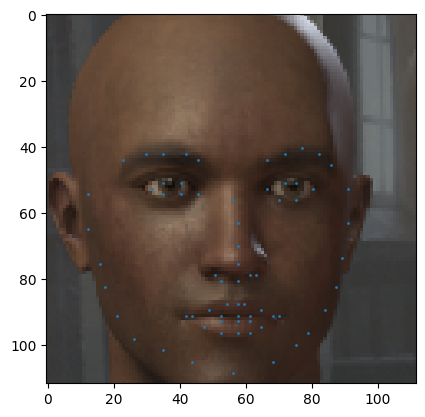

In [30]:
i = np.random.randint(0, 100)
plot_landmarks(medium_geneset.alligned_images[i], landmarks[i].view(-1, 2).numpy() * 112)

# PCA Combined v1 medium geneset

In [123]:
import utils.training
importlib.reload(utils.training)
from utils.training import pca_combined_features_v1

combined_features_medium, medium_pcas = pca_combined_features_v1(medium_geneset)
combined_features_celeba, _ = pca_combined_features_v1(celeba_dataset, medium_pcas)
np.save(DATA_DIR / "celeba_sample_embeddings" / "embeddings_pca_combined_v1", combined_features_celeba)
np.save(DATA_DIR / "medium_geneset_embeddings" / "embeddings_pca_combined_v1", combined_features_medium)

## Medium - arcface-100

In [127]:
import utils.dataset 
import models.mlp 
importlib.reload(utils.dataset)
importlib.reload(models.mlp)
from utils.dataset import get_raw_dataset
# train test split for combined features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from models.mlp import MLP, train_mlp

X, Y = get_raw_dataset("medium")
X_train, X_test, Y_train, Y_test, medium_images_train, medium_images_test = train_test_split(X, Y, medium_geneset.alligned_images, test_size=0.1, random_state=42)
scaler_x = MinMaxScaler()
scaler_x.fit(X_train)
X_train_sc = scaler_x.transform(X_train)
X_test_sc = scaler_x.transform(X_test)
print(f"shape of dataset: {X.shape}, {Y.shape}")

mlp_medium_arcface = train_mlp(
    X_train_sc,
    X_test_sc,
    Y_train,
    Y_test,
    medium_images_test,
    DATA_DIR / f"experiments/medium-arcface-r100",
    "medium",
    "arcface-r100",
    force=True
)

100%|██████████| 7/7 [00:00<00:00, 150.00it/s]


shape of dataset: (30299, 35), (30299, 512)


/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:396: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type         | Params | Mode 
-----------------------------------------------
0 | model | DNARegressor | 543 K  | train
-----------------------------------------------
543 K     Trainable params
0         Non-trainable params
543 K     Total params
2.173     Total estimated model params size (MB)


/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 8: 100%|██████████| 214/214 [00:02<00:00, 86.64it/s, v_num=ej5m, train_loss_step=0.0273, val_loss=0.0288, train_loss_epoch=0.0291, RMSE=0.169, Scaled RMSE=0.169, MAE=0.123, R2=0.031]  


MAE,█▁
R2,▁█
RMSE,█▁
Scaled RMSE,█▁
epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇████
train_loss_epoch,█▁▁▁▁▁▁▁▁
train_loss_step,█▆▃▇▅▅▇▃▃▄▅▄▅▄▆▃▃▃▇▆▄▄▆▆▅▆▆▁▅█▂▄▅▃▆▆▂▃
trainer/global_step,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇███
val_loss,▆▅▅▃█▁▅▄▂
MAE,0.12291
R2,0.03096


## Medium mlp v2 - pca-combined-v1

In [271]:
import utils.dataset 
importlib.reload(utils.dataset)
importlib.reload(models.mlp)
from utils.dataset import get_raw_dataset
# train test split for combined features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from models.mlp import MLP, train_mlp


class DNARegressorV2(nn.Module):
    INFO = "dropout + batchnorm"
    def __init__(self, input_size, output_size, hidden_sizes: list[int]):
        super(DNARegressorV2, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_size, hidden_sizes[0]))
        for i in range(1, len(hidden_sizes)):
            self.layers.append(nn.Linear(hidden_sizes[i-1], hidden_sizes[i]))
            self.layers.append(nn.BatchNorm1d(hidden_sizes[i]))
            self.layers.append(nn.ReLU())
            self.layers.append(nn.Dropout(0.5))
        self.layers.append(nn.Linear(hidden_sizes[-1], output_size))
    
    def forward(self, x):
        for layer in self.layers[:-1]:
            x = layer(x)
        x = self.layers[-1](x)
        return x

GENESET = "easy"
FEATURES = "landmarks"
images = easy_geneset.alligned_images
X, Y = get_raw_dataset(GENESET, FEATURES)
X_train, X_test, Y_train, Y_test, medium_images_train, medium_images_test = train_test_split(X, Y, images, test_size=0.1, random_state=42)
pca = PCA(0.95).fit(Y_train)
Y_train = pca.transform(Y_train)
Y_test = pca.transform(Y_test)
scaler_x = MinMaxScaler()
scaler_x.fit(X_train)
X_train_sc = scaler_x.transform(X_train)
X_test_sc = scaler_x.transform(X_test)
print(f"shape of dataset: {X.shape}, {Y.shape}")


mlp_medium_pca_combined = train_mlp(
    X_train_sc,
    X_test_sc,
    Y_train,
    Y_test,
    medium_images_test,
    DATA_DIR / f"../experiments/{GENESET}_geneset/mlp-v2/{FEATURES}",
    GENESET,
    feature_names=FEATURES,
    force=True,
    model_raw=DNARegressorV2(input_size=Y_train.shape[1], output_size=X_train.shape[1], hidden_sizes=[512, 512, 512]),
    model_raw_name="mlp+dropout+batchnorm + SGD",
    lr=1e-4,
)


100%|██████████| 7/7 [00:00<00:00, 186.97it/s]


shape of dataset: (30332, 13), (30332, 136)


/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:208: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (mps), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:396: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
INFO:pytorch_lightning.callbacks.model_summary:
  | Name  | Type           | Params | Mode 
-------------------------------------------------
0 | model | 

Sanity Checking:   0%|          | 0/2 [00:00<?, ?it/s]

/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


/Users/maciej.czyjt/private/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Epoch 59: 100%|██████████| 214/214 [00:03<00:00, 69.72it/s, v_num=eg25, train_loss_step=0.0113, val_loss=0.0147, train_loss_epoch=0.0101, RMSE=0.120, Scaled RMSE=0.120, MAE=0.0915, R2=0.390] 

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=60` reached.


Epoch 59: 100%|██████████| 214/214 [00:03<00:00, 69.62it/s, v_num=eg25, train_loss_step=0.0113, val_loss=0.0147, train_loss_epoch=0.0101, RMSE=0.120, Scaled RMSE=0.120, MAE=0.0915, R2=0.390]


In [221]:
mlp_medium_pca_combined(torch.tensor(Y[:100])).shape

torch.Size([100, 13])

In [229]:
from utils.dataset import normalize 

_, pcas = pca_combined_features_v1(easy_geneset)
pca_features_v1_celeba, _ = pca_combined_features_v1(celeba_dataset, pcas)
celeba_dataset.model2normalized_embeddings["pca-combined-v1"] = normalize(pca_features_v1_celeba)
test_skin_color_correlation(mlp_medium_pca_combined.eval(), "easy", -1, easy_geneset, FEATURES, celeba_dataset)

100%|██████████| 7/7 [00:00<00:00, 138.84it/s]
474it [00:00, 1962.29it/s]                         


(CK) skin color feature vs skin color proxy: corr = 0.9725059620525863
(CK) skin color proxy vs skin color prediction: corr = 0.9708281630681305


157it [00:00, 1577.14it/s]             

(real) skin color proxy vs skin color prediction: corr = 0.13841952250946965


In [195]:
min_col = scaler_x.inverse_transform(X_pred).argmin() % X_pred.shape[1]
MEDIUIM_GENESET_GENES[min_col]

'gene_bs_nose_height.nose_height_pos'

In [203]:
X_train[:,  -4].min()

0

(array([13666.,   881.,  1045.,  1312.,  1332.,  1265.,  1357.,  1310.,
         2561.,  2540.]),
 array([  0. ,  25.5,  51. ,  76.5, 102. , 127.5, 153. , 178.5, 204. ,
        229.5, 255. ]),
 <BarContainer object of 10 artists>)

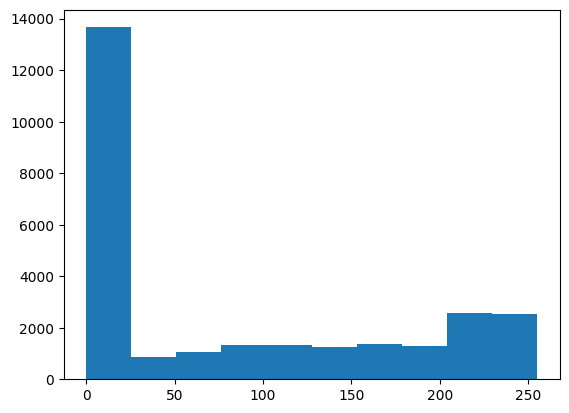

In [204]:
plt.hist(X_train[:, -4])

In [ ]:
plt.hist(X_test[:, min_col])

In [206]:
importlib.reload(utils.dna)
mlp_medium_pca_combined.eval().to("cpu")
X_pred = batch_predict(mlp_medium_pca_combined, torch.tensor(Y_test), 64)
X_pred = torch.concatenate(X_pred).detach().numpy()
pred_path = Path(f"../../experiments/medium_geneset_embeddings/predicted_dnas_mlp")
save_predicitons(X_pred, scaler_x, pred_path, "medium")

48it [00:00, 1278.63it/s]             
100%|██████████| 7/7 [00:00<00:00, 134.28it/s]


# pca-combined-v1 Celeba proxy skin regression

In [29]:
import utils.dataset 
import models.mlp
importlib.reload(utils.dataset)
importlib.reload(models.mlp)
from utils.dataset import get_raw_dataset
# train test split for combined features
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from models.mlp import MLP, train_mlp
import torch.nn as nn


class DNARegressorV2(nn.Module):
    INFO = "dropout + batchnorm"
    def __init__(self, input_size, output_size, hidden_sizes: list[int]):
        super(DNARegressorV2, self).__init__()
        self.layers = nn.ModuleList()
        self.layers.append(nn.Linear(input_size, hidden_sizes[0]))
        for i in range(1, len(hidden_sizes)):
            self.layers.append(nn.Linear(hidden_sizes[i-1], hidden_sizes[i]))
            self.layers.append(nn.BatchNorm1d(hidden_sizes[i]))
            self.layers.append(nn.ReLU())
            self.layers.append(nn.Dropout(0.5))
        self.layers.append(nn.Linear(hidden_sizes[-1], output_size))
    
    def forward(self, x):
        for layer in self.layers[:-1]:
            x = layer(x)
        x = self.layers[-1](x)
        return x

GENESET = "celeba-sample1k"
FEATURES = "pca-combined-v1"
images = celeba_dataset.alligned_images
Y = celeba_dataset.model2normalized_embeddings[FEATURES]
X = np.array([estimate_skin_darkness(i) for i in images]).reshape(-1, 1)
X_train, X_test, Y_train, Y_test, medium_images_train, medium_images_test = train_test_split(X, Y, images, test_size=0.1, random_state=42)
# pca = PCA(0.95).fit(Y_train)
# Y_train = pca.transform(Y_train)
# Y_test = pca.transform(Y_test)
# scaler_x = MinMaxScaler()
# scaler_x.fit(X_train)
# X_train_sc = scaler_x.transform(X_train)
# X_test_sc = scaler_x.transform(X_test)
print(f"shape of dataset: {X.shape}, {Y.shape}")


mlp_medium_pca_combined = train_mlp(
    X_train,
    X_test,
    Y_train,
    Y_test,
    medium_images_test,
    DATA_DIR / f"../experiments/{GENESET}_geneset/mlp-v2/{FEATURES}",
    GENESET,
    feature_names=FEATURES,
    force=True,
    model_raw=DNARegressorV2(input_size=Y_train.shape[1], output_size=X_train.shape[1], hidden_sizes=[512, 512, 512]),
    model_raw_name="mlp+dropout+batchnorm",
    lr=1e-5,
)


shape of dataset: (9997, 1), (9997, 114)


/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:199: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:391: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.

  | Name  | Type           | Params
-----------------------------------------
0 | model | DNARegressorV2 | 586 K 
-----------------------------------------
586 K     Trainable params
0         Non-trainable params
586 K     Total params
2.347     Total estimated model params size (MB)


/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/czyjtu/dev/prompt2avatar/venv/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Epoch 12: 100%|██████████| 71/71 [00:01<00:00, 65.06it/s, v_num=mqxf, train_loss_step=0.0165, val_loss=0.0185, train_loss_epoch=0.0155, RMSE=0.146, Scaled RMSE=0.146, MAE=0.115, R2=0.0528]


MAE,▅█▁
R2,▁▂█
RMSE,█▇▁
Scaled RMSE,█▇▁
epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
train_loss_epoch,█▂▁▁▁▁▁▁▁▁▁▁▁
train_loss_step,█▃▂▂▂▂▁▁▁▁▁▁▁▂▁▁▂▁
trainer/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇██
val_loss,█▆▂▃▅▇▁▁▃▂▄▁▂
MAE,0.11534
R2,0.05282


(array([ 41., 158., 300., 238., 140.,  72.,  26.,  11.,   8.,   6.]),
 array([0.0196971 , 0.11626123, 0.21282536, 0.30938949, 0.40595362,
        0.50251775, 0.59908188, 0.69564601, 0.79221014, 0.88877427,
        0.9853384 ]),
 <BarContainer object of 10 artists>)

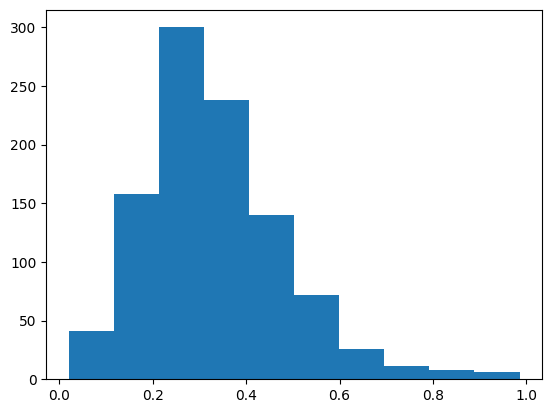

In [21]:
plt.hist(X_test)



(array([442., 259., 125.,  75.,  49.,  24.,  15.,   7.,   3.,   1.]),
 array([0.19889122, 0.25972655, 0.32056192, 0.38139725, 0.44223261,
        0.50306797, 0.56390327, 0.62473863, 0.685574  , 0.7464093 ,
        0.80724466]),
 <BarContainer object of 10 artists>)

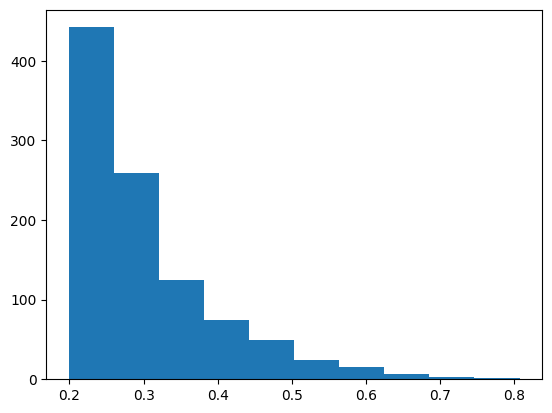

In [22]:
Y_pred_proxyceleba = mlp_medium_pca_combined.eval().to("cpu")(torch.tensor(Y_test)).detach().numpy()
plt.hist(Y_pred_proxyceleba)

# CLIP embeddings

In [7]:
from utils.training import get_clip_embeddings

for dataset, target_path in zip([easy_geneset, medium_geneset, celeba_dataset, test_geneset], ["easy_geneset", "medium_geneset", "celeba_sample", "test_geneset"]):
    embeddings = get_clip_embeddings(dataset.alligned_images).detach().cpu()
    print(target_path, embeddings.shape)
    np.save(f"../../data/{target_path}_embeddings/embeddings_clip.npy", embeddings)

948it [3:06:08, 11.78s/it]                             


easy_geneset torch.Size([30332, 1024])


947it [2:51:28, 10.86s/it]                           


medium_geneset torch.Size([30299, 1024])


313it [56:02, 10.74s/it]                         


celeba_sample torch.Size([9997, 1024])


469it [1:24:44, 10.84s/it]                         

test_geneset torch.Size([14990, 1024])


# brudnopis 

In [111]:
from utils.training import get_clip_embeddings

n = 100 
embeds = get_clip_embeddings(medium_geneset.alligned_images[:n])
embeds.shape

4it [00:38,  9.70s/it]                       


torch.Size([100, 1024])

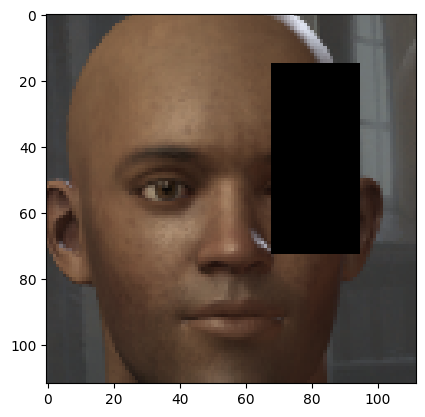

In [110]:
import torchvision.transforms as VT

t = VT.Compose([
    VT.ToTensor(),
    VT.RandomErasing(p=1, scale=(0.01, 0.2)),
    VT.ToPILImage()
])
plt.imshow(t(medium_geneset.alligned_images[0]))

In [75]:
import utils.face_recognition as ufr
importlib.reload(ufr)
import utils.face_recognition as ufr
m2 = load_insightface_model("../../thirdparty/recognition/weights/arcface_r100.pth").eval()
layers_to_hook = [list(k for k in dict(m2.named_modules()).keys() if f"layer{i}" in k)[-1] for i in range(1, 5)]
features1 = ufr.get_earlier_layers_features(m2.to("cpu"), layers_to_hook, medium_geneset.alligned_images[:100], "cpu")
features2 = get_earlier_layers_features(m2.to("cpu"), layers_to_hook, medium_geneset.alligned_images[:100])

100%|██████████| 100/100 [00:00<00:00, 3010.32it/s]
4it [00:11,  2.76s/it]                       
100%|██████████| 100/100 [00:00<00:00, 1892.54it/s]
2it [00:09,  4.79s/it]                       


In [76]:
for f1, f2 in zip(features1, features2):
    print(f1.shape, f2.shape)
    print(f1.mean(), f2.mean(), f1.std(), f2.std())
    print(np.allclose(f1.astype("float16"), f2.astype("float16")))

(100, 64) (100, 64)
0.006788844 0.006788844 0.06746403 0.06746403
True
(100, 128) (100, 128)
0.000441382 0.0004413821 0.08751919 0.08751919
False
(100, 256) (100, 256)
-0.0013387816 -0.0013387814 0.10861183 0.10861183
False
(100, 512) (100, 512)
-8.91468e-05 -8.9146735e-05 0.021749768 0.021749768
False


In [50]:
f1.dtype

dtype('float32')

In [8]:
layer_names = ["_".join(l.split(".")) for l in layers_to_hook]
layer_names

['layer1_2_bn3', 'layer2_12_bn3', 'layer3_29_bn3', 'layer4_2_bn3']

In [28]:
DATASET_PATH = DATA_DIR / "celeba_sample_embeddings"#f"{GENESET}_geneset_embeddings"
IMAGES_PATH = DATASET_PATH / "alligned_images.npy"
imagesv1 = np.load(IMAGES_PATH)
imagesv1.shape
images = np.moveaxis(imagesv1, -1, 1)

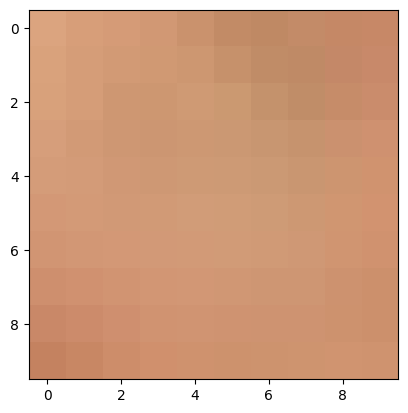

0.633490282352941


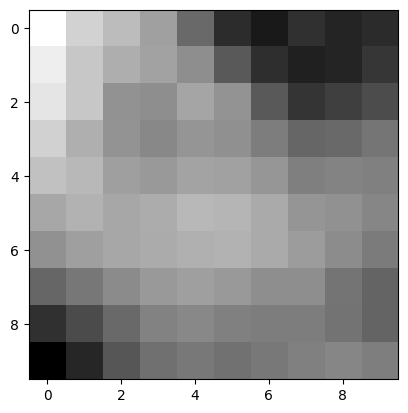

In [18]:
save_features_from_layers(model, layers_to_hook, np.moveaxis(easy_geneset.alligned_images, -1, 1), DATA_DIR / "easy_geneset_embeddings")

 37%|███▋      | 173/473 [19:58<2:04:26, 24.89s/it]

: 

In [10]:
easy_geneset.alligned_images.shape

(30332, 112, 112, 3)